# HCI Car Simulation_Data Analysis

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import re
import pandas as pd
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from scipy.optimize import differential_evolution, minimize
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.tree import plot_tree

from scripts import twoddynamics, oneddynamics, databuilder, readsubcategoryrating, intensity_calculation, demographics, plotter, optim, machinelearning


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

# 0. Load data and write data dictionary

In [4]:
phase = "phaseI"
sub_nums = np.setdiff1d(np.arange(1,27,1), [12, 25])

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
data_dir = DATA_DIR / phase

df_phase = pd.read_csv(data_dir / "PhaseI_Block.csv")
df_pattern = pd.read_csv(data_dir / "RecommendationPatterns.csv")

df_subcategory_rating = pd.read_csv(data_dir / "Rating_subcategory.csv")
df_subcategory_rating = readsubcategoryrating.format(df_subcategory_rating)

df_subject_prior = pd.read_csv(DATA_DIR / "sub_prior.csv")
df_subject_prior = readsubcategoryrating.format_prior(df_subject_prior)

df_demographics = pd.read_csv(DATA_DIR / "demographics.csv")
df_demographics = readsubcategoryrating.format_demographics(df_demographics)


=== driving experience ===
mean   : 5.976
median : 5.000
std    : 5.475
n      : 25

=== age ===
mean   : 25.240
median : 25.000
std    : 4.075
n      : 25

=== gender ===
        count  ratio
gender              
male       17   0.68
female      6   0.24
other       2   0.08

=== nationality ===
                  count  ratio
nationality                   
china                16   0.64
united states         5   0.20
bangladeshi           1   0.04
turkey                1   0.04
israel                1   0.04
iranian american      1   0.04

=== driver license ===
                count  ratio
driver license              
yes                25    1.0

=== education level ===
                 count  ratio
education level              
undergraduate       19   0.76
master's             6   0.24

=== driving frequency ===
                   count  ratio
driving frequency              
daily                 10   0.40
2-3 times a week       5   0.20
4-6 times a week       5   0.20
once a wee

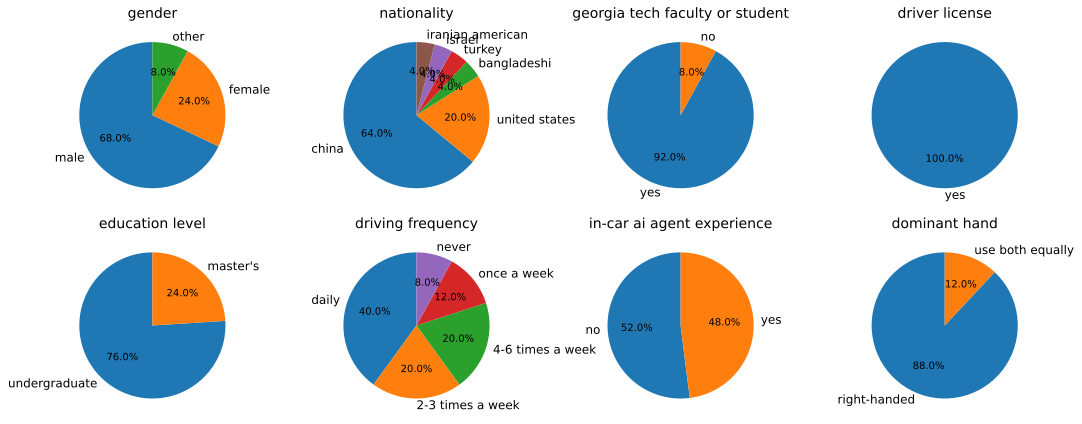

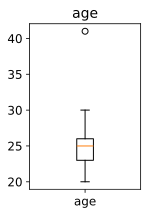

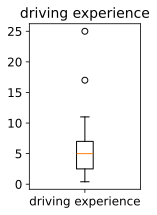

In [353]:
demographics_results = demographics.summarize(df_demographics)
demographics.print_report(demographics_results)
demographics.plot_demographics(df_demographics,
                               figsize_cat=(15, 6),
                               figsize_cont=(2, 3),
                            )

In [5]:
stimuli_intensity_dict = intensity_calculation.intensity_calculation(data_dir / "recommendation_intensity_features.csv")
data_dict = defaultdict(dict)

for sub in sub_nums:
    sub_key = f"sub_{sub}"
    sub_dirs = sorted(data_dir.glob(f"sub_{sub}_*"))
    assert len(sub_dirs) == 3, f"sub{sub} has more than 3 folders"

    for j, sub_dir in enumerate(sub_dirs):
        block = j + 4 if sub % 2 == 0 else j + 1
        row = df_phase[(df_phase["Sub"] == sub) & (df_phase["Block"] == block)].iloc[0]

        sub_rating = df_subcategory_rating[(df_subcategory_rating["sub_id"] == sub) & (df_subcategory_rating["block_id"] == block)]

        scene_key = f"scene_{row['SceneID']}"

        marker_df = pd.read_csv(sub_dir / "Marker.csv")
        car_df = pd.read_csv(sub_dir / "PawnCar.csv", index_col=0)

        marker_df["_time_ms"] = pd.to_numeric(marker_df["unixtimestamp_ms"], errors="coerce")
        car_df["_time_ms"] = pd.to_numeric(car_df.index, errors="coerce")
        car_df = car_df.reset_index(drop=True)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        stimuli_file_path = sub_dir / "recommendation_intensity_features.csv"
        if stimuli_file_path.exists():
            sub_stimuli_intensity_dict = intensity_calculation.intensity_calculation(stimuli_file_path)
        else:
            sub_stimuli_intensity_dict = stimuli_intensity_dict

        data_dict[sub_key][scene_key] = {
            "marker": marker_df,
            "car": car_df,
            "subcategory_rating": sub_rating,
            "stimuli_intensity": sub_stimuli_intensity_dict,
            "pattern": df_pattern[df_pattern["PatternID"] == row["PatternID"]],
        }

In [13]:
def build_trial_level_df(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            df = trial["marker"]

            if scene_key == "scene_4":
                verison = "personalized"
                scene_key = "scene_3"
            elif scene_key == "scene_5":
                verison = "personified"
                scene_key = "scene_3"
            else:
                verison = "default"

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")

            df["accept_bin"] = (df["reaction"] == "accept").astype(int)

            for _, row in df.iterrows():
                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "version": verison,
                    "driving": driving,
                    "type": int(row["type"]),
                    "accept": row["accept_bin"]
                })

    return pd.DataFrame(records)

df_trial = build_trial_level_df(data_dict)

# 1. Mixed Effect Modeling
## 1.1 LMM treat sub as random intercept

In [357]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "accept ~ C(driving, Sum) * C(scene, Sum) * C(type, Sum)",
    df_trial,
    groups=df_trial["sub"]
)

result = model.fit()
print(result.summary())

def test_effect(result, terms):
    print("\nTesting:", terms)
    print(result.wald_test(terms))

# main effects
test_effect(result, "C(driving, Sum)[S.auto] = 0")
test_effect(result, "C(type, Sum)[S.1] = 0")
test_effect(result, """
C(scene, Sum)[S.scene_1] = 0,
C(scene, Sum)[S.scene_2] = 0
""")

                                    Mixed Linear Model Regression Results
Model:                              MixedLM                   Dependent Variable:                   accept   
No. Observations:                   722                       Method:                               REML     
No. Groups:                         24                        Scale:                                0.1953   
Min. group size:                    30                        Log-Likelihood:                       -477.3342
Max. group size:                    31                        Converged:                            Yes      
Mean group size:                    30.1                                                                     
-------------------------------------------------------------------------------------------------------------
                                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


## 1.1 Treat Type Independently

In [358]:
for t in [1, 2]:
    df_sub = df_trial[df_trial["type"] == t]
    
    print(f"\n=== Type {t} ===")
    model = smf.mixedlm(
        "accept ~ C(driving, Sum) * C(scene, Sum)",
        df_sub,
        groups=df_sub["sub"]
    )
    result = model.fit()
    print(result.summary())

    # ===== main effects =====
    print("\n-- Main Effects --")
    
    # driving
    print("\nDriving effect:")
    print(result.wald_test("C(driving, Sum)[S.auto] = 0"))
    
    # scene（joint test）
    print("\nScene effect:")
    print(result.wald_test("""
        C(scene, Sum)[S.scene_1] = 0,
        C(scene, Sum)[S.scene_2] = 0
    """))
    
    # ===== interaction =====
    print("\n-- Interaction --")
    
    print("\nDriving × Scene:")
    print(result.wald_test("""
        C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_1] = 0,
        C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_2] = 0
    """))


=== Type 1 ===
                           Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             accept   
No. Observations:             360                 Method:                         REML     
No. Groups:                   24                  Scale:                          0.1725   
Min. group size:              15                  Log-Likelihood:                 -214.5998
Max. group size:              15                  Converged:                      Yes      
Mean group size:              15.0                                                         
-------------------------------------------------------------------------------------------
                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------
Intercept                                         0.753    0.030 25.211 0.000  0.694  0.811

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


## 1.2 LMM treat sub as random slope

In [359]:
model = smf.mixedlm(
    "accept ~ driving * scene * type",
    df_trial,
    groups=df_trial["sub"],
    re_formula="~type"
)

result = model.fit()
print(result.summary())

                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          accept   
No. Observations:          722              Method:                      REML     
No. Groups:                24               Scale:                       0.1942   
Min. group size:           30               Log-Likelihood:              -463.7539
Max. group size:           31               Converged:                   Yes      
Mean group size:           30.1                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                                1.000    0.129  7.766 0.000  0.748  1.252
driving[T.manual]                       -0.167    0.182 -0.915 0.360 -0.524  0.190
scene[T.scene_2]           

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


# 2. Acceptance rate description

In [360]:
def extract_reaction_stats(data_dict):
    records = []

    for sub_key, scenes in data_dict.items():
        sub = int(sub_key.split("_")[1])
        driving = "auto" if sub % 2 == 0 else "manual"

        for scene_key, trial in scenes.items():
            if scene_key == "scene_4":
                version = "personalized"
                scene_key = "scene_3"
            elif scene_key == "scene_5":
                version = "personified"
                scene_key = "scene_3"
            else:
                version = "default"

            df = trial["marker"]

            df = df[df["marker"].str.startswith("reaction")].copy()
            if len(df) == 0:
                continue

            df["type"] = df["current_encode_id"].astype(str).str[0]
            df["reaction"] = df["marker"].str.replace("reaction_", "")
            df["pattern"] = df["current_encode_id"].astype(str)
            df["type_sub"] = df["pattern"].str[1:3]

            for t in ["1", "2"]:
                sub_df = df[df["type"] == t]
                if len(sub_df) == 0:
                    continue

                total = len(sub_df)
                counts = sub_df["reaction"].value_counts()

                records.append({
                    "sub": sub,
                    "scene": scene_key,
                    "version": version,
                    "driving": driving,
                    "type": int(t),
                    "accept": counts.get("accept", 0)/total,
                    "reject": counts.get("reject", 0)/total,
                    "ignore": counts.get("ignore", 0)/total,
                })

    return pd.DataFrame(records)

In [361]:
import seaborn as sns
import matplotlib.pyplot as plt

type_palette = {
    1: "#1D9CFF",
    2: "#FFA51C",
}

driving_mode_palette = {
    'auto': "#651DFF",
    'manual': "#FFA51C",
}

def plot_scene_box(df):
    for metric in ["accept", "reject", "ignore"]:
        for t in [1, 2]:
            plt.figure(figsize=(8,5))
            sns.boxplot(
                data=df[df["type"]==t],
                x="scene",
                y=metric,
                hue="driving"
            )
            plt.title(f"{metric} (Type {t}) across scenes")
            plt.xticks(rotation=30)
            plt.show()

def plot_scene_facet(df):
    for metric in ["accept", "reject", "ignore"]:
        g = sns.catplot(
            data=df,
            x="scene",
            y=metric,
            hue="driving",
            col="type",
            kind="box",
            height=4,
            aspect=1.2
        )
        g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=30)
        plt.show()

def plot_type_facet(df, col="scene"):
    for metric in ["accept"]:
        g = sns.catplot(
            data=df,
            x="type",
            y=metric,
            hue="type",
            palette=type_palette,
            col=col,
            kind="bar",
            errorbar="se",
            height=3,
            aspect=0.75,
            alpha=0.75,
            edgecolor="black",
            legend=False,
        )
        
        # g.fig.suptitle(f"{metric} ratio (scene x driving x type)", y=1.05)
        g.set_titles("{col_name}")
        g.set_xticklabels(["type 1", "type 2"])
        g.set_axis_labels("", f"{metric} ratio")

        for ax in g.axes.flat:
            ax.tick_params(axis='x', rotation=0)
            ax.set_ylim(0, 1)
            ax.set_yticks(np.linspace(0, 1, 6))
        
        plt.show()

In [362]:
from scipy.stats import mannwhitneyu, wilcoxon

def summarize_scene(df):
    summary = df.groupby(["scene","driving","type"]).agg(
        accept_mean=("accept","mean"),
        reject_mean=("reject","mean"),
        ignore_mean=("ignore","mean"),
        n=("sub","count")
    ).reset_index()

    print(summary)
    return summary

from scipy.stats import mannwhitneyu

def test_driving_per_scene(df):
    print("\n=== Driving effect per scene ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for scene in df["scene"].unique():
            for t in [1,2]:
                sub_df = df[(df["scene"]==scene) & (df["type"]==t)]

                g1 = sub_df[sub_df["driving"]=="manual"][metric]
                g2 = sub_df[sub_df["driving"]=="auto"][metric]

                if len(g1)>0 and len(g2)>0:
                    _, p = mannwhitneyu(g1, g2)
                    print(f"{scene}, type{t}: p={p:.4f}")

from scipy.stats import friedmanchisquare

def test_scene_effect(df):
    print("\n=== Scene effect ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index="sub",
                columns="scene",
                values=metric
            ).dropna()

            if pivot.shape[1] >= 3:
                stat, p = friedmanchisquare(*[pivot[c] for c in pivot.columns])
                print(f"type{t}: p={p:.4f}")

def test_interaction_proxy(df):
    print("\n=== Interaction proxy (Δscene effect between driving) ===")

    for metric in ["accept","reject","ignore"]:
        print(f"\n--- {metric} ---")

        for t in [1,2]:
            sub_df = df[df["type"]==t]

            pivot = sub_df.pivot_table(
                index=["sub","driving"],
                columns="scene",
                values=metric
            ).dropna()

            pivot["range"] = pivot.max(axis=1) - pivot.min(axis=1)

            manual = pivot[pivot.index.get_level_values("driving")=="manual"]["range"]
            auto   = pivot[pivot.index.get_level_values("driving")=="auto"]["range"]

            if len(manual)>0 and len(auto)>0:
                _, p = mannwhitneyu(manual, auto)
                print(f"type{t}: p={p:.4f}")

from scipy.stats import mannwhitneyu

def test_scene_type_diff(df):
    print("\n=== Type1 vs Type2 difference within each scene ===")

    for metric in ["accept", "reject", "ignore"]:
        print(f"\n--- {metric} ---")

        for scene in sorted(df["scene"].unique()):
            scene_df = df[df["scene"] == scene]

            type1 = scene_df.loc[scene_df["type"] == 1, metric].dropna()
            type2 = scene_df.loc[scene_df["type"] == 2, metric].dropna()

            if len(type1) > 0 and len(type2) > 0:
                stat, p = mannwhitneyu(type1, type2, alternative="two-sided")
                print(
                    f"{scene}: "
                    f"type1(n={len(type1)}, mean={type1.mean():.3f}, median={type1.median():.3f}) | "
                    f"type2(n={len(type2)}, mean={type2.mean():.3f}, median={type2.median():.3f}) | "
                    f"U={stat:.3f}, p={p:.4f}"
                )
            else:
                print(f"{scene}: insufficient data")

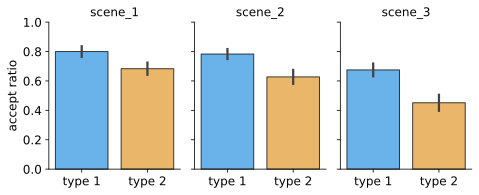

      scene driving  type  accept_mean  reject_mean  ignore_mean   n
0   scene_1    auto     1     0.816667     0.083333     0.100000  12
1   scene_1    auto     2     0.633333     0.316667     0.050000  12
2   scene_1  manual     1     0.783333     0.100000     0.116667  12
3   scene_1  manual     2     0.733333     0.166667     0.100000  12
4   scene_2    auto     1     0.816667     0.116667     0.066667  12
5   scene_2    auto     2     0.566667     0.366667     0.066667  12
6   scene_2  manual     1     0.750000     0.183333     0.066667  12
7   scene_2  manual     2     0.688889     0.230556     0.080556  12
8   scene_3    auto     1     0.783333     0.200000     0.016667  12
9   scene_3    auto     2     0.416667     0.516667     0.066667  12
10  scene_3  manual     1     0.566667     0.316667     0.116667  12
11  scene_3  manual     2     0.486111     0.347222     0.166667  12

=== Type1 vs Type2 difference within each scene ===

--- accept ---
scene_1: type1(n=24, mean=0.800, m

In [363]:
df_stats = extract_reaction_stats(data_dict)

# plot_scene_facet(df_stats)
plot_type_facet(df_stats)

summary = summarize_scene(df_stats)

# test_driving_per_scene(df_stats)
# test_scene_effect(df_stats)
# test_interaction_proxy(df_stats)
test_scene_type_diff(df_stats)

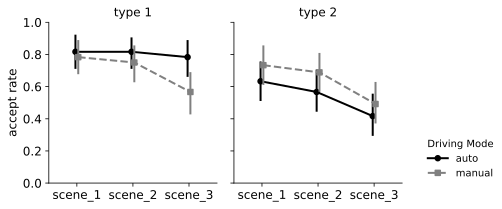

In [364]:
df_trial["driving"] = df_trial["driving"].astype("category")
df_trial["scene"] = df_trial["scene"].astype("category")
df_trial["type"] = df_trial["type"].astype("category")

# plt.figure(figsize=(3,3))

g = sns.catplot(
    data=df_trial,
    x="scene",
    y="accept",
    hue="driving",
    col="type",
    kind="point",
    dodge=True,
    errorbar=('ci', 95),
    height=3,
    aspect=0.8,
    palette=["black", "gray"],
    markers=["o", "s"],
    linestyles=["-", "--"],
    linewidth = 2.0,
)

g.set_axis_labels("", "accept rate")
g.set_titles("type {col_name}")
g._legend.set_bbox_to_anchor((1.0, 0.1))
g._legend.set_loc("lower left")
g._legend.set_title("Driving Mode")
# g.fig.suptitle(
#     "Accept Rate by Scene, Driving Mode, and Type",
#     y=1.0,
#     ha='center'
# )

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))

plt.tight_layout()
plt.show()

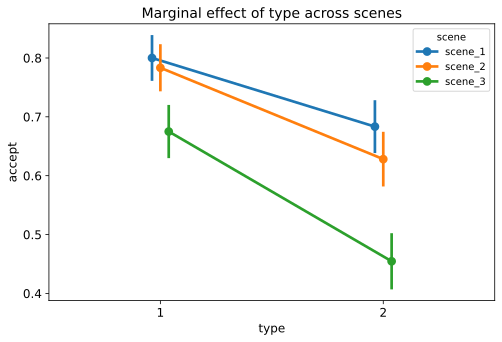

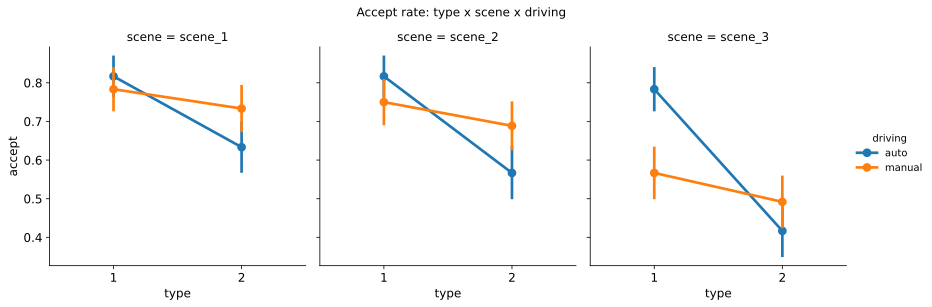

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_2811/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_2811/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_2811/2013965643.py:36: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain

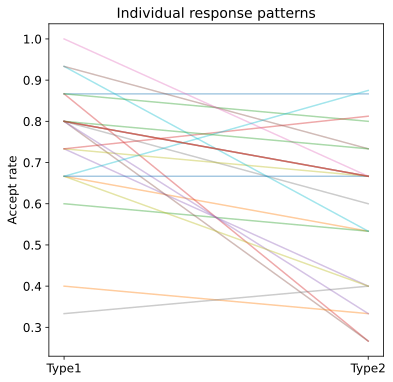

In [365]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.pointplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="scene",
    dodge=True,
    errorbar="se"
)

plt.title("Marginal effect of type across scenes")
plt.show()

g = sns.catplot(
    data=df_trial,
    x="type",
    y="accept",
    hue="driving",
    col="scene",
    kind="point",
    errorbar="se",
    height=4,
    aspect=1,
)

g.fig.suptitle("Accept rate: type x scene x driving", y=1.05)
plt.show()

plt.figure(figsize=(6,6))

for sub in df_trial["sub"].unique():
    sub_df = df_trial[df_trial["sub"]==sub]
    pivot = sub_df.pivot_table(index="type", values="accept", aggfunc="mean")

    plt.plot([1,2], pivot.values.flatten(), alpha=0.4)

plt.xticks([1,2], ["Type1", "Type2"])
plt.ylabel("Accept rate")
plt.title("Individual response patterns")
plt.show()

## 3. Subject clustering

In [366]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot.columns = ["accept_type1", "accept_type2"]
pivot["diff"] = pivot["accept_type1"] - pivot["accept_type2"]

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_2811/1223868461.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


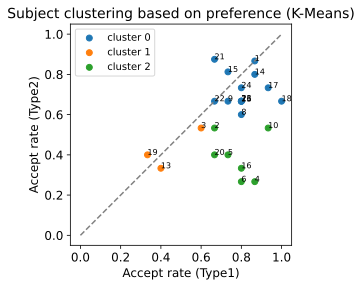

In [367]:
from sklearn.cluster import KMeans

X = pivot[["accept_type1", "accept_type2"]].values

kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
pivot["cluster"] = kmeans.labels_

plt.figure(figsize=(4,4))

for c in sorted(pivot["cluster"].unique()):
    sub_df = pivot[pivot["cluster"]==c]
    plt.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )
    for idx, row in sub_df.iterrows():
        plt.text(
            row["accept_type1"],
            row["accept_type2"],
            str(idx),
            fontsize=8
        )

plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("Accept rate (Type1)")
plt.ylabel("Accept rate (Type2)")
# plt.xticks(np.linspace(0, 1, 11))
# plt.yticks(np.linspace(0, 1, 11))
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title("Subject clustering based on preference (K-Means)")
plt.show()

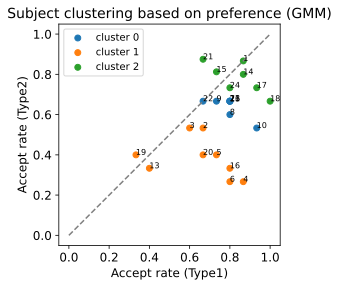

In [368]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

X = pivot[["accept_type1", "accept_type2"]].values

gmm = GaussianMixture(n_components=3, random_state=42)
pivot["cluster"] = gmm.fit_predict(X)

fig, ax = plt.subplots(figsize=(4, 4))

for c in sorted(pivot["cluster"].unique()):
    sub_df = pivot[pivot["cluster"] == c]
    ax.scatter(
        sub_df["accept_type1"],
        sub_df["accept_type2"],
        label=f"cluster {c}"
    )
    for idx, row in sub_df.iterrows():
        plt.text(
            row["accept_type1"],
            row["accept_type2"],
            str(idx),
            fontsize=8
        )

ax.set_xlabel("Accept rate (Type1)")
ax.set_ylabel("Accept rate (Type2)")
ax.set_aspect("equal", adjustable="box")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.legend()
ax.set_title("Subject clustering based on preference (GMM)")

plt.show()

In [369]:
pivot = df_trial.pivot_table(
    index="sub",
    columns="type",
    values="accept",
    aggfunc="mean"
)

pivot["diff"] = pivot[1] - pivot[2]
print(pivot)

type         1         2      diff
sub                               
1     0.866667  0.866667  0.000000
2     0.666667  0.533333  0.133333
3     0.600000  0.533333  0.066667
4     0.866667  0.266667  0.600000
5     0.733333  0.400000  0.333333
6     0.800000  0.266667  0.533333
7     0.800000  0.666667  0.133333
8     0.800000  0.600000  0.200000
9     0.733333  0.666667  0.066667
10    0.933333  0.533333  0.400000
11    0.800000  0.666667  0.133333
13    0.400000  0.333333  0.066667
14    0.866667  0.800000  0.066667
15    0.733333  0.812500 -0.079167
16    0.800000  0.333333  0.466667
17    0.933333  0.733333  0.200000
18    1.000000  0.666667  0.333333
19    0.333333  0.400000 -0.066667
20    0.666667  0.400000  0.266667
21    0.666667  0.875000 -0.208333
22    0.666667  0.666667  0.000000
23    0.800000  0.666667  0.133333
24    0.800000  0.733333  0.066667
26    0.800000  0.666667  0.133333


/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_2811/1211643864.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_trial.pivot_table(


# 4. Per-reaction modeling

For each reaction, we aggregate trial-level features into the following groups.

---

### Meta

- `sub_id`: subject ID (`int`)
- `scene_id`: scene ID (`int`)
- `mode`: driving mode (`int`)
- `recommendation`: recommendation code (`int`, 5 digits)
- `recommendation_category`: recommendation category (`int`, 1 digit)
- `recommendation_subcategory`: recommendation subcategory (`int`, 3 digits)

---

### Prior

These variables describe the participant’s baseline tendency and behavioral state before the current recommendation.

- `subject_prior`: subject-level prior probability of accepting this recommendation subcategory (`float`)
- `mean_steering_input`: mean steering input (`float`)
- `var_steering_input`: variance of steering input (`float`)
- `mean_throttle_input`: mean throttle input (`float`)
- `var_throttle_input`: variance of throttle input (`float`)

---

### Scenario

These variables describe the current recommendation and the driving context around the reaction.

- `intensity`: intensity of the recommendation (`float`)
- `coherence`: coherence of the recommendation (`float`)
- `mean_steering_input_zscore_pre2s`: mean steering input z-score in the 2 s pre-reaction window (`float`)
- `mean_throttle_input_zscore_pre2s`: mean throttle input z-score in the 2 s pre-reaction window (`float`)

---

### Reaction

These variables describe the behavioral response to the recommendation.

- `accept`: whether the recommendation was accepted (`bool`)
- `reaction_time_ms`: reaction time in milliseconds (`float`)
- `mean_steering_input_zscore_post5s`: mean steering input z-score in the 5 s post-reaction window (`float`)
- `mean_throttle_input_zscore_post5s`: mean throttle input z-score in the 5 s post-reaction window (`float`)

---

### Evaluation

These variables describe the participant’s subjective evaluation after the reaction.

- `disturbance`: perceived disturbance (`float`)
- `satisfaction`: subjective satisfaction (`float`)
- `appropriateness`: perceived appropriateness (`float`)

---

## Dynamic Modeling Goal

We build a dynamical decision model that takes **prior** and **scenario** variables as inputs to predict whether a recommendation is **accepted**.

The model is designed to capture the competition between latent **accept** and **reject** decision states over time.

---

## Modeling Assumption

We assume that the biological time constant of the decision dynamics is the same across participants.

In other words:

- the accept-state time constant is shared across subjects
- the reject-state time constant is shared across subjects

This means that individual differences are modeled mainly through:

- prior acceptance tendency
- scenario-dependent inputs
- reaction-specific context

rather than through subject-specific intrinsic time constants.


In [90]:
df_reaction = databuilder.build_per_reaction_df(
    data_dict,
    pre_window_ms=2000,
    post_window_ms=5000,
    # df_subject_prior=df_subject_prior,
)

# print(df_reaction["prior_mean_throttle_input"].head())

## 4.1 Subcategory Disturbance, Satisfaction and Appropriateness

In [371]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

df = df_reaction.copy()

df["scene_id"] = df["scene_id"].astype("category")
df["mode"] = df["mode"].astype("category")
df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")
df["sub_id"] = df["sub_id"].astype("category")

metrics = ["appropriateness", "disturbance", "satisfaction"]

In [372]:
for col in ["recommendation_subcategory", "scene_id", "mode"]+metrics:
    print(col, df[col].isna().sum(), df[col].dtype)

recommendation_subcategory 0 category
scene_id 0 category
mode 0 category
appropriateness 0 int16
disturbance 0 int16
satisfaction 0 int16


In [373]:
overall_results = []

for metric in metrics:
    formula = f"{metric} ~ C(recommendation_subcategory, Sum) * scene_id * mode"
    model_all = smf.mixedlm(
        formula,
        df,
        groups=df["sub_id"]
    ).fit(reml=False)

    print("\n" + "="*80)
    print(f"OVERALL MODEL FOR {metric}")
    print("="*80)
    print(model_all.summary())

    coef_table = pd.DataFrame({
        "term": model_all.params.index,
        "coef": model_all.params.values,
        "pval": model_all.pvalues.values
    })
    coef_table["metric"] = metric
    overall_results.append(coef_table)
    terms = [
        t for t in model_all.params.index
        if "C(recommendation_subcategory, Sum)" in t
        and ":" not in t
    ]

    hypothesis = ", ".join([f"{t} = 0" for t in terms])

    print(model_all.wald_test(hypothesis))

overall_results_df = pd.concat(overall_results, ignore_index=True)


OVERALL MODEL FOR appropriateness
                                      Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  appropriateness
No. Observations:                    722                      Method:                              ML             
No. Groups:                          24                       Scale:                               2.1074         
Min. group size:                     30                       Log-Likelihood:                      -1314.5462     
Max. group size:                     31                       Converged:                           Yes            
Mean group size:                     30.1                                                                         
------------------------------------------------------------------------------------------------------------------
                                                                        Coef.  Std.E

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, 

In [374]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# =========================================================
# 0) 基础准备
# =========================================================
df = df_reaction.copy()

if not isinstance(df["recommendation_subcategory"].dtype, pd.CategoricalDtype):
    df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")

if not isinstance(df["recommendation_category"].dtype, pd.CategoricalDtype):
    df["recommendation_category"] = df["recommendation_category"].astype("category")

subcat_levels = list(df["recommendation_subcategory"].cat.categories)
category_levels = list(df["recommendation_category"].cat.categories)


# =========================================================
# 1) 每个 subcategory 内部:
#    metric ~ scene_id * mode
# =========================================================
per_subcat_results = []
per_subcat_models = {}

for subcat in subcat_levels:
    df_sub = df[df["recommendation_subcategory"] == subcat].copy()

    if len(df_sub) == 0:
        continue

    for metric in metrics:
        formula = f"{metric} ~ scene_id * mode"

        try:
            model = smf.mixedlm(
                formula,
                df_sub,
                groups=df_sub["sub_id"]
            ).fit(reml=False)

            per_subcat_models[(subcat, metric)] = model

            for term in model.params.index:
                per_subcat_results.append({
                    "subcategory": subcat,
                    "metric": metric,
                    "term": term,
                    "coef": model.params.get(term, np.nan),
                    "pval": model.pvalues.get(term, np.nan)
                })

        except Exception as e:
            print(f"Per-subcat model failed for subcategory={subcat}, metric={metric}: {e}")

per_subcat_results_df = pd.DataFrame(per_subcat_results)


# =========================================================
# 2) FDR by (metric, term)
# =========================================================
def add_fdr_by_group(df_in, group_cols=("metric", "term"), p_col="pval"):
    df_out = df_in.copy()
    df_out["pval_fdr"] = np.nan

    if len(df_out) == 0:
        return df_out

    grouped = df_out.groupby(list(group_cols), dropna=False)

    for _, idx in grouped.groups.items():
        idx = list(idx)
        pvals = df_out.loc[idx, p_col].astype(float).values
        mask = ~np.isnan(pvals)

        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            idx_arr = np.array(idx)
            df_out.loc[idx_arr[mask], "pval_fdr"] = corrected

    return df_out

per_subcat_results_df = add_fdr_by_group(per_subcat_results_df)


# =========================================================
# 3) 汇总 scene / mode / interaction
# =========================================================
summary_rows = []

for subcat in subcat_levels:
    df_subcat = df[df["recommendation_subcategory"] == subcat].copy()
    if len(df_subcat) == 0:
        continue

    # 找到这个 subcategory 对应的 category
    cat_vals = df_subcat["recommendation_category"].dropna().unique()
    category = cat_vals[0] if len(cat_vals) > 0 else np.nan

    for metric in metrics:
        df_tmp = per_subcat_results_df[
            (per_subcat_results_df["subcategory"] == subcat) &
            (per_subcat_results_df["metric"] == metric)
        ].copy()

        scene_terms = df_tmp[
            df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            ~df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        mode_terms = df_tmp[
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        interaction_terms = df_tmp[
            df_tmp["term"].str.contains("scene_id", regex=False, na=False) &
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        summary_rows.append({
            "recommendation_category": category,
            "subcategory": subcat,
            "metric": metric,
            "scene_min_p": scene_terms["pval"].min() if len(scene_terms) else np.nan,
            "scene_min_p_fdr": scene_terms["pval_fdr"].min() if len(scene_terms) else np.nan,
            "mode_min_p": mode_terms["pval"].min() if len(mode_terms) else np.nan,
            "mode_min_p_fdr": mode_terms["pval_fdr"].min() if len(mode_terms) else np.nan,
            "interaction_min_p": interaction_terms["pval"].min() if len(interaction_terms) else np.nan,
            "interaction_min_p_fdr": interaction_terms["pval_fdr"].min() if len(interaction_terms) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)


# =========================================================
# 4) category 内部 mixed model:
#    metric ~ C(recommendation_subcategory, Sum) + mode
#
#    这里检验的是：
#    每个 subcategory 是否显著偏离其所属 recommendation_category 内部均值
# =========================================================
def parse_sum_term_level(term):
    # e.g. C(recommendation_subcategory, Sum)[S.101] -> "101"
    if "[S." in term:
        return term.split("[S.")[-1].rstrip("]")
    return None


def cast_level_to_match_categories(level_str, categories):
    if len(categories) == 0:
        return level_str

    first = categories[0]

    try:
        if isinstance(first, (int, np.integer)):
            return int(level_str)
        elif isinstance(first, (float, np.floating)):
            return float(level_str)
        else:
            return str(level_str)
    except Exception:
        return level_str


def wald_pvalue(test_obj):
    return float(np.asarray(test_obj.pvalue).reshape(-1)[0])


def get_subcategory_vs_mean_from_model(model, subcat_levels_local):
    params = model.params.index.tolist()

    main_terms = [
        t for t in params
        if "C(recommendation_subcategory, Sum)" in t and ":" not in t
    ]

    if len(main_terms) == 0:
        raise ValueError("No main-effect sum-coded subcategory terms found in model.")

    results = []
    mapped_levels = []

    # 显式显示的 levels
    for term in main_terms:
        lvl_raw = parse_sum_term_level(term)
        lvl = cast_level_to_match_categories(lvl_raw, subcat_levels_local)
        mapped_levels.append(lvl)

        test = model.wald_test(f"{term} = 0", scalar=True)

        results.append({
            "subcategory": lvl,
            "subcat_coef": model.params[term],
            "subcat_p": wald_pvalue(test)
        })

    # 隐含最后一个 level
    missing_levels = [lvl for lvl in subcat_levels_local if lvl not in mapped_levels]

    if len(missing_levels) == 1:
        last_level = missing_levels[0]
        expr = " + ".join(main_terms) + " = 0"
        test = model.wald_test(expr, scalar=True)

        results.append({
            "subcategory": last_level,
            "subcat_coef": -sum(model.params[t] for t in main_terms),
            "subcat_p": wald_pvalue(test)
        })

    elif len(missing_levels) > 1:
        raise ValueError(f"More than one missing level inferred: {missing_levels}")

    res_df = pd.DataFrame(results)
    res_df["subcategory"] = pd.Categorical(
        res_df["subcategory"],
        categories=subcat_levels_local,
        ordered=True
    )
    res_df = res_df.sort_values("subcategory").reset_index(drop=True)
    res_df["subcategory"] = res_df["subcategory"].astype(object)

    return res_df


category_subcat_effect_rows = []
category_factor_tests = []
category_models = {}

for metric in metrics:
    for rec_cat in sorted(df["recommendation_category"].dropna().unique()):
        df_cat = df[df["recommendation_category"] == rec_cat].copy()

        if len(df_cat) == 0:
            continue

        # 去掉未使用的 subcategory levels，避免奇异矩阵
        if isinstance(df_cat["recommendation_subcategory"].dtype, pd.CategoricalDtype):
            df_cat["recommendation_subcategory"] = (
                df_cat["recommendation_subcategory"]
                .cat.remove_unused_categories()
            )
        else:
            df_cat["recommendation_subcategory"] = (
                df_cat["recommendation_subcategory"].astype("category")
            )

        subcat_levels_local = list(df_cat["recommendation_subcategory"].cat.categories)

        if len(subcat_levels_local) < 2:
            category_factor_tests.append({
                "metric": metric,
                "recommendation_category": rec_cat,
                "subcategory_overall_chi2": np.nan,
                "subcategory_overall_p": np.nan,
                "subcategory_df": np.nan,
            })
            continue

        # 只保留 subcategory 和 mode，不再建模 version
        fixed_terms = ["C(recommendation_subcategory, Sum)"]

        if df_cat["mode"].nunique(dropna=True) > 1:
            fixed_terms.append("mode")

        formula = f"{metric} ~ " + " + ".join(fixed_terms)

        try:
            model_cat = smf.mixedlm(
                formula,
                df_cat,
                groups=df_cat["sub_id"]
            ).fit(reml=False)

            category_models[(rec_cat, metric)] = model_cat

            main_terms = [
                t for t in model_cat.params.index
                if "C(recommendation_subcategory, Sum)" in t and ":" not in t
            ]

            if len(main_terms) > 0:
                joint_expr = ", ".join([f"{t} = 0" for t in main_terms])
                joint_test = model_cat.wald_test(joint_expr, scalar=True)

                category_factor_tests.append({
                    "metric": metric,
                    "recommendation_category": rec_cat,
                    "subcategory_overall_chi2": float(np.asarray(joint_test.statistic).reshape(-1)[0]),
                    "subcategory_overall_p": float(np.asarray(joint_test.pvalue).reshape(-1)[0]),
                    "subcategory_df": len(main_terms),
                })

                subcat_effect_df = get_subcategory_vs_mean_from_model(
                    model_cat,
                    subcat_levels_local=subcat_levels_local
                )
                subcat_effect_df["recommendation_category"] = rec_cat
                subcat_effect_df["metric"] = metric
                category_subcat_effect_rows.append(subcat_effect_df)
            else:
                category_factor_tests.append({
                    "metric": metric,
                    "recommendation_category": rec_cat,
                    "subcategory_overall_chi2": np.nan,
                    "subcategory_overall_p": np.nan,
                    "subcategory_df": np.nan,
                })

        except Exception as e:
            print(f"Within-category model failed for category={rec_cat}, metric={metric}: {e}")
            category_factor_tests.append({
                "metric": metric,
                "recommendation_category": rec_cat,
                "subcategory_overall_chi2": np.nan,
                "subcategory_overall_p": np.nan,
                "subcategory_df": np.nan,
            })


if len(category_subcat_effect_rows) > 0:
    category_subcat_effect_df = pd.concat(category_subcat_effect_rows, ignore_index=True)
else:
    category_subcat_effect_df = pd.DataFrame(
        columns=[
            "subcategory",
            "metric",
            "recommendation_category",
            "subcat_coef",
            "subcat_p"
        ]
    )

category_factor_tests_df = pd.DataFrame(category_factor_tests)


# =========================================================
# 5) FDR for subcategory-vs-category-mean
#    在每个 (metric, recommendation_category) 内做 FDR
# =========================================================
category_subcat_effect_df["subcat_p_fdr"] = np.nan

if len(category_subcat_effect_df) > 0:
    for metric in metrics:
        for rec_cat in category_subcat_effect_df["recommendation_category"].dropna().unique():
            idx = (
                (category_subcat_effect_df["metric"] == metric) &
                (category_subcat_effect_df["recommendation_category"] == rec_cat)
            )
            pvals = category_subcat_effect_df.loc[idx, "subcat_p"].astype(float).values
            mask = ~np.isnan(pvals)

            if mask.sum() > 0:
                corrected = multipletests(pvals[mask], method="fdr_bh")[1]
                idx_arr = category_subcat_effect_df.index[idx].to_numpy()
                category_subcat_effect_df.loc[idx_arr[mask], "subcat_p_fdr"] = corrected


# =========================================================
# 6) merge
# =========================================================

# 避免 notebook 里重复运行后出现 recommendation_category_x / _y
cols_to_drop = [
    c for c in summary_df.columns
    if c in ["recommendation_category", "recommendation_category_x", "recommendation_category_y"]
]
if len(cols_to_drop) > 0:
    summary_df = summary_df.drop(columns=cols_to_drop)

subcat_cat_map = (
    df[["recommendation_subcategory", "recommendation_category"]]
    .drop_duplicates()
    .rename(columns={"recommendation_subcategory": "subcategory"})
)

summary_df = summary_df.merge(
    subcat_cat_map,
    on="subcategory",
    how="left"
)

summary_df = summary_df.merge(
    category_subcat_effect_df[
        [
            "subcategory",
            "metric",
            "recommendation_category",
            "subcat_coef",
            "subcat_p",
            "subcat_p_fdr",
        ]
    ],
    on=["subcategory", "metric", "recommendation_category"],
    how="left"
)

summary_df = summary_df.merge(
    category_factor_tests_df,
    on=["metric", "recommendation_category"],
    how="left"
)

summary_df = summary_df.sort_values(
    ["metric", "recommendation_category", "subcategory"]
).reset_index(drop=True)

# =========================================================
# 7) significance flags
# =========================================================
alpha = 0.05
summary_df["scene_sig"] = summary_df["scene_min_p_fdr"] < alpha
summary_df["mode_sig"] = summary_df["mode_min_p_fdr"] < alpha
summary_df["interaction_sig"] = summary_df["interaction_min_p_fdr"] < alpha
summary_df["subcat_vs_category_mean_sig"] = summary_df["subcat_p_fdr"] < alpha
summary_df["subcategory_overall_sig"] = summary_df["subcategory_overall_p"] < alpha

display(summary_df)
summary_df.to_csv("Output/phase_I_subcategory_analysis_summary.csv", index=False)

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


,subcategory,metric,scene_min_p,scene_min_p_fdr,mode_min_p,mode_min_p_fdr,interaction_min_p,interaction_min_p_fdr,recommendation_category,subcat_coef,subcat_p,subcat_p_fdr,subcategory_overall_chi2,subcategory_overall_p,subcategory_df,scene_sig,mode_sig,interaction_sig,subcat_vs_category_mean_sig,subcategory_overall_sig
0,101,appropriateness,3.751876e-01,5.620891e-01,0.227142,0.757141,0.059947,0.299735,1,0.811111,1.488869e-07,3.722173e-07,85.955574,9.510814e-18,4,False,False,False,True,True
1,102,appropriateness,5.491221e-02,2.238071e-01,1.000000,1.000000,0.415413,0.593447,1,0.450000,3.558573e-03,5.930955e-03,85.955574,9.510814e-18,4,False,False,False,True,True
2,103,appropriateness,4.395293e-01,5.620891e-01,0.360351,0.900879,0.218766,0.447805,1,0.088889,5.647685e-01,7.059606e-01,85.955574,9.510814e-18,4,False,False,False,False,True
3,104,appropriateness,1.319028e-01,1.943592e-01,0.051150,0.511498,0.110035,0.353993,1,-0.050000,7.460346e-01,7.460346e-01,85.955574,9.510814e-18,4,False,False,False,False,True
4,105,appropriateness,4.269234e-06,4.269234e-05,0.808633,1.000000,0.057893,0.299735,1,-1.300000,3.742944e-17,1.871472e-16,85.955574,9.510814e-18,4,True,False,False,True,True
5,201,appropriateness,4.241921e-04,2.120961e-03,0.813987,1.000000,0.530148,0.662685,2,0.207940,2.378124e-01,2.972655e-01,17.857593,1.315738e-03,4,True,False,False,False,True
6,202,appropriateness,1.224041e-01,1.943592e-01,0.797985,1.000000,0.395561,0.662685,2,0.128570,4.698022e-01,4.698022e-01,17.857593,1.315738e-03,4,False,False,False,False,True
7,203,appropriateness,1.360514e-01,1.943592e-01,0.917239,1.000000,0.223903,0.447805,2,-0.232541,1.911096e-01,2.972655e-01,17.857593,1.315738e-03,4,False,False,False,False,True
8,204,appropriateness,7.859332e-02,1.943592e-01,0.104934,0.524669,0.141597,0.353993,2,-0.593652,8.456364e-04,4.228182e-03,17.857593,1.315738e-03,4,False,False,False,True,True
9,205,appropriateness,2.264361e-02,7.547871e-02,0.906258,1.000000,0.132498,0.447805,2,0.489682,5.906894e-03,1.476723e-02,17.857593,1.315738e-03,4,False,False,False,True,True


In [375]:
from itertools import combinations
from scipy.stats import ttest_rel

pairwise_rows = []

for metric in metrics:
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    wide = agg.pivot(index="sub_id", columns="recommendation_subcategory", values=metric)

    for a, b in combinations(wide.columns, 2):
        paired = wide[[a, b]].dropna()
        if len(paired) >= 2:
            stat, pval = ttest_rel(paired[a], paired[b])
            pairwise_rows.append({
                "metric": metric,
                "subcat_a": a,
                "subcat_b": b,
                "n_subjects": len(paired),
                "mean_a": paired[a].mean(),
                "mean_b": paired[b].mean(),
                "mean_diff": (paired[a] - paired[b]).mean(),
                "pval": pval
            })

pairwise_df = pd.DataFrame(pairwise_rows)

# FDR per metric
pairwise_df["pval_fdr"] = np.nan
for metric in metrics:
    idx = pairwise_df["metric"] == metric
    if idx.sum() > 0:
        pairwise_df.loc[idx, "pval_fdr"] = multipletests(
            pairwise_df.loc[idx, "pval"],
            method="fdr_bh"
        )[1]

pairwise_df = pairwise_df.sort_values(["metric", "pval_fdr"])
pairwise_df.head(20)

,metric,subcat_a,subcat_b,n_subjects,mean_a,mean_b,mean_diff,pval,pval_fdr
3,appropriateness,101,105,24,6.458333,4.347222,2.111111,1.163566e-07,0.000002
6,appropriateness,101,203,24,6.458333,4.388889,2.069444,8.041874e-08,0.000002
7,appropriateness,101,204,24,6.458333,4.027778,2.430556,1.472679e-07,0.000002
5,appropriateness,101,202,24,6.458333,4.750000,1.708333,2.041035e-06,0.000023
4,appropriateness,101,201,24,6.458333,4.829861,1.628472,5.282305e-06,0.000048
15,appropriateness,102,204,24,6.097222,4.027778,2.069444,1.591541e-05,0.000119
14,appropriateness,102,203,24,6.097222,4.388889,1.708333,7.332097e-05,0.000471
11,appropriateness,102,105,24,6.097222,4.347222,1.750000,1.103179e-04,0.000607
22,appropriateness,103,204,24,5.736111,4.027778,1.708333,1.213913e-04,0.000607
8,appropriateness,101,205,24,6.458333,5.111111,1.347222,1.532245e-04,0.000690


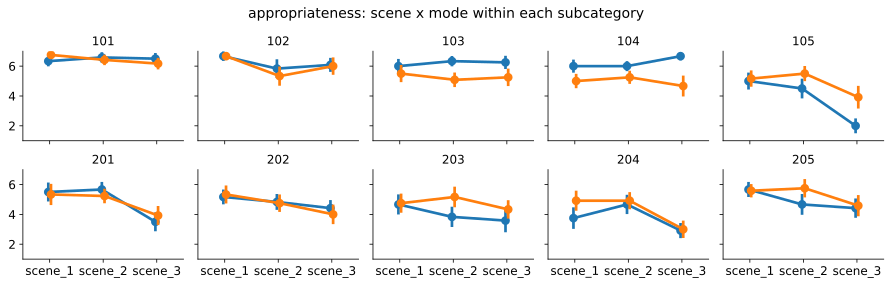

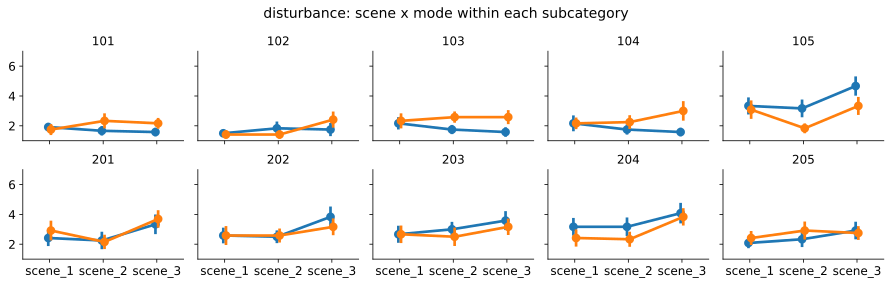

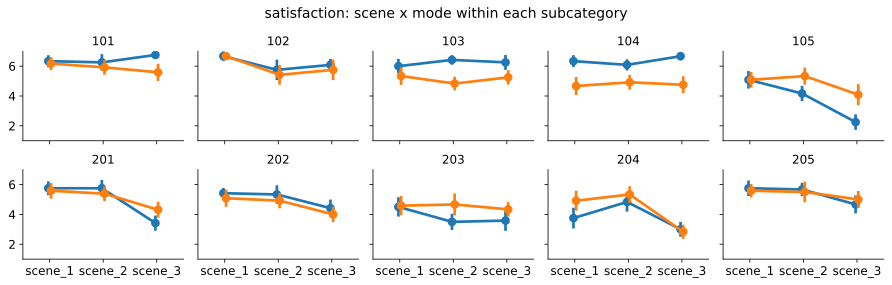

In [376]:
for metric in metrics:
    g = sns.catplot(
        data=df_reaction,
        x="scene_id",
        y=metric,
        hue="mode",
        col="recommendation_subcategory",
        kind="point",
        errorbar="se",
        dodge=True,
        col_wrap=5,
        height=2,
        aspect=1.25,
        legend=False,
        sharey=True,
    )

    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        ax.set_ylim(1, 7)
        ax.set_yticks([2, 4, 6])
        ax.set_xlabel("")
        ax.set_ylabel("")

    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(f"{metric}: scene x mode within each subcategory", fontsize=14)

    plt.tight_layout()
    plt.show()

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_2811/3971230992.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_means = df.groupby("recommendation_category")[metric].mean()
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_2811/3971230992.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_means = df.groupby("recommendation_category")[metric].mean()
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_2811/3971230992.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retai

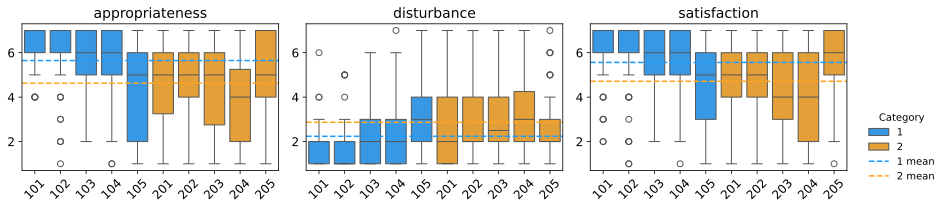

In [377]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    ax = axes[i] if len(metrics) > 1 else axes

    sns.boxplot(
        data=df,
        x="recommendation_subcategory",
        y=metric,
        hue="recommendation_category",
        palette=type_palette,
        ax=ax
    )

    # ===== type-level mean =====
    type_means = df.groupby("recommendation_category")[metric].mean()

    for t, mean_val in type_means.items():
        ax.axhline(
            y=mean_val,
            linestyle="--",
            linewidth=1.5,
            color=type_palette.get(t, "gray"),
            alpha=1.0,
            label=f"{t} mean"
        )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")

    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

# fig.suptitle("Overall difference across subcategories", fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(
    handles, labels,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.0, 0.1),
    frameon=False
)

plt.show()

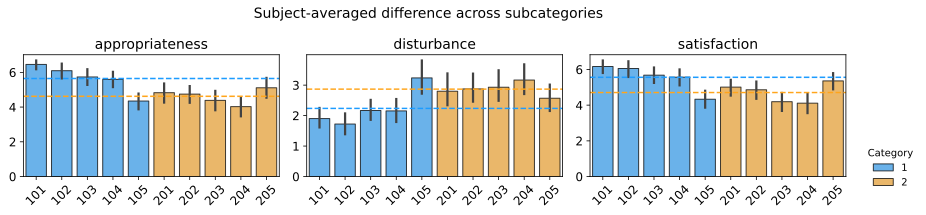

In [378]:
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))

for i, metric in enumerate(metrics):
    agg = (
        df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
        .mean()
        .reset_index()
    )

    agg["category"] = agg["recommendation_subcategory"].astype(int) // 100

    # type/category 的整体均值
    type_means = agg.groupby("category")[metric].mean()

    ax = axes[i] if len(metrics) > 1 else axes

    sns.barplot(
        data=agg,
        x="recommendation_subcategory",
        y=metric,
        hue="category",
        palette=type_palette,
        edgecolor = "black",
        alpha = 0.75,
        ax=ax
    )

    # 画不同 type 的均值横线
    for cat, mean_val in type_means.items():
        ax.axhline(
            y=mean_val,
            color=type_palette.get(cat, "gray"),
            linestyle="--",
            linewidth=1.5,
            alpha=1.0,
        )

    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")

    if ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

fig.suptitle("Subject-averaged difference across subcategories", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 1])

fig.legend(
    handles,
    labels,
    title="Category",
    loc="lower left",
    bbox_to_anchor=(1.0, 0.1),
    frameon=False
)

plt.show()

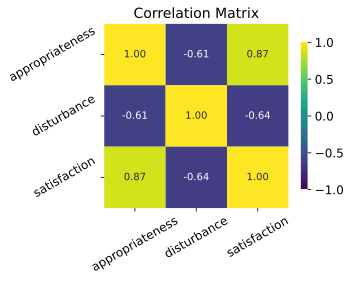

In [379]:
df_reaction[["appropriateness", "disturbance", "satisfaction"]].corr()

import seaborn as sns
import matplotlib.pyplot as plt

cols = ["appropriateness", "disturbance", "satisfaction"]
corr = df_reaction[cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=30)
plt.yticks(rotation=30)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

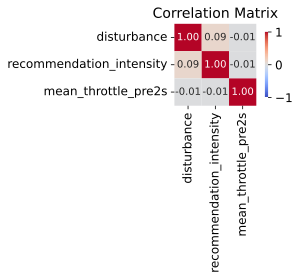

In [380]:
df_reaction[["disturbance", "recommendation_intensity", "mean_throttle_pre2s"]].corr()

import seaborn as sns
import matplotlib.pyplot as plt

cols = ["disturbance", "recommendation_intensity", "mean_throttle_pre2s"]
corr = df_reaction[cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Phase II

In [83]:
phase_II = "phaseII"
# sub_nums_II = [3,5,7,8,11,16,19,20,22,]
sub_nums_II = [3,4,5,7,8,9,11,16,19,20,22,24]

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
data_dir_II = DATA_DIR / phase_II

df_subcategory_rating_II = pd.read_csv(data_dir_II / "Rating_subcategory.csv")
df_subcategory_rating_II = readsubcategoryrating.format(df_subcategory_rating_II)

In [84]:
print(df_subcategory_rating_II['version'].unique())

['Personalized' 'Personified']


In [85]:
data_dict_II = defaultdict(dict)
stimuli_intensity_dict = intensity_calculation.intensity_calculation(data_dir / "recommendation_intensity_features.csv")

for sub in sub_nums_II:
    sub_key = f"sub_{sub}"
    sub_dirs = sorted(data_dir_II.glob(f"sub_{sub}_*"))
    assert len(sub_dirs) == 2, f"sub {sub} has more than 2 folders"

    for j, sub_dir in enumerate(sub_dirs):
        scene_key = "scene_4" if (sub %2 == 1 and j % 2 == 0) or (sub %2 == 0 and j % 2 == 1) else "scene_5"
        version = "personalized" if (sub %2, j % 2) == (1,0) or (sub %2, j % 2) == (0,1) else "personified"

        row = df_phase[(df_phase["Sub"] == sub) & (df_phase["Block"] == block)].iloc[0]

        sub_rating = df_subcategory_rating_II[(df_subcategory_rating_II["sub_id"] == sub) & (df_subcategory_rating_II["version"].str.lower() == version)]
        if sub_rating.empty:
            print(f"Warning: no subcategory rating found for sub {sub}, version {version}")
            sub_rating = None

        marker_df = pd.read_csv(sub_dir / "Marker.csv")
        car_df = pd.read_csv(sub_dir / "PawnCar.csv", index_col=0)

        marker_df["_time_ms"] = pd.to_numeric(marker_df["unixtimestamp_ms"], errors="coerce")
        car_df["_time_ms"] = pd.to_numeric(car_df.index, errors="coerce")
        car_df = car_df.reset_index(drop=True)

        marker_df.columns = marker_df.columns.str.strip().str.lower()
        car_df.columns = car_df.columns.str.strip().str.lower()

        stimuli_file_path = sub_dir / "recommendation_intensity_features.csv"
        if stimuli_file_path.exists():
            sub_stimuli_intensity_dict = intensity_calculation.intensity_calculation(stimuli_file_path)
        else:
            sub_stimuli_intensity_dict = stimuli_intensity_dict

        data_dict_II[sub_key][scene_key] = {
            "marker": marker_df,
            "car": car_df,
            "subcategory_rating": sub_rating,
            "stimuli_intensity": sub_stimuli_intensity_dict,
            "pattern": df_pattern[df_pattern["PatternID"] == row["PatternID"]],
        }

df_trial_II = build_trial_level_df(data_dict_II)
print(f"Number of trials for each version:")
for sub in sub_nums_II:
    for version in ["personalized", "personified"]:
        count = df_trial_II[
            (df_trial_II["sub"] == sub) &
            (df_trial_II["version"] == version)
        ].shape[0]
        print(f"Sub {sub}, Version {version}: {count} trials")

assert df_trial_II[df_trial_II['version']=='personalized'].shape[0] == df_trial_II[df_trial_II['version']=='personified'].shape[0], "Version counts do not match"

df_trial_baseline = df_trial[
    (df_trial['sub'].isin(sub_nums_II)) &
    (df_trial['scene'] == 'scene_3')
]

df_trial_merge_II = pd.concat([df_trial_baseline, df_trial_II], ignore_index=True)

Number of trials for each version:
Sub 3, Version personalized: 10 trials
Sub 3, Version personified: 10 trials
Sub 4, Version personalized: 10 trials
Sub 4, Version personified: 10 trials
Sub 5, Version personalized: 10 trials
Sub 5, Version personified: 10 trials
Sub 7, Version personalized: 10 trials
Sub 7, Version personified: 10 trials
Sub 8, Version personalized: 10 trials
Sub 8, Version personified: 10 trials
Sub 9, Version personalized: 10 trials
Sub 9, Version personified: 10 trials
Sub 11, Version personalized: 10 trials
Sub 11, Version personified: 10 trials
Sub 16, Version personalized: 10 trials
Sub 16, Version personified: 10 trials
Sub 19, Version personalized: 10 trials
Sub 19, Version personified: 10 trials
Sub 20, Version personalized: 10 trials
Sub 20, Version personified: 10 trials
Sub 22, Version personalized: 10 trials
Sub 22, Version personified: 10 trials
Sub 24, Version personalized: 10 trials
Sub 24, Version personified: 10 trials


In [384]:
print(df_trial_II['version'].unique())

['personalized' 'personified']


In [422]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "accept ~ version * type * driving",
    df_trial_merge_II,
    groups=df_trial_merge_II["sub"]
)

result = model.fit()
print(result.summary())

def test_effect(result, terms):
    print("\nTesting:", terms)
    print(result.wald_test(terms))

# main effects
test_effect(result, "version[T.personified] = 0")
test_effect(result, "version[T.personalized] = 0")
test_effect(result, "type = 0")
test_effect(result, "version[T.personalized]:type  = 0")
# test_effect(result, "C(type, Sum)[S.1] = 0")

                          Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            accept   
No. Observations:             360                Method:                        REML     
No. Groups:                   12                 Scale:                         0.1860   
Min. group size:              30                 Log-Likelihood:                -224.1444
Max. group size:              30                 Converged:                     Yes      
Mean group size:              30.0                                                       
-----------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                       1.133    0.178  6.365 0.000  0.784  1.482
version[T.personalized]             

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [386]:
for t in [1, 2]:
    df_sub = df_trial_merge_II[df_trial_merge_II["type"] == t]
    
    print(f"\n=== Type {t} ===")
    model = smf.mixedlm(
        "accept ~ version * driving",
        df_sub,
        groups=df_sub["sub"]
    )
    result = model.fit()
    print(result.summary())

    # # ===== main effects =====
    # print("\n-- Main Effects --")
    
    # # driving
    # print("\nDriving effect:")
    # print(result.wald_test("C(driving, Sum)[S.auto] = 0"))
    
    # # scene（joint test）
    # print("\nScene effect:")
    # print(result.wald_test("""
    #     C(scene, Sum)[S.scene_1] = 0,
    #     C(scene, Sum)[S.scene_2] = 0
    # """))
    
    # # ===== interaction =====
    # print("\n-- Interaction --")
    
    # print("\nDriving × Scene:")
    # print(result.wald_test("""
    #     C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_1] = 0,
    #     C(driving, Sum)[S.auto]:C(scene, Sum)[S.scene_2] = 0
    # """))


=== Type 1 ===
                       Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          accept   
No. Observations:            180              Method:                      REML     
No. Groups:                  12               Scale:                       0.1986   
Min. group size:             15               Log-Likelihood:              -116.6164
Max. group size:             15               Converged:                   No       
Mean group size:             15.0                                                   
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.733    0.082  8.971 0.000  0.573  0.894
version[T.personalized]                    0.133    0.115  1.159 0.247 -0

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

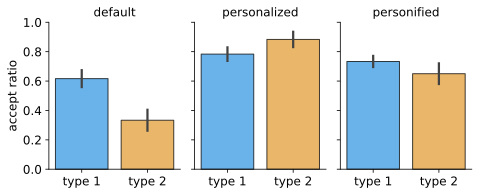

     scene driving  type  accept_mean  reject_mean  ignore_mean   n
0  scene_3    auto     1     0.800000     0.200000     0.000000  18
1  scene_3    auto     2     0.544444     0.433333     0.022222  18
2  scene_3  manual     1     0.622222     0.244444     0.133333  18
3  scene_3  manual     2     0.700000     0.211111     0.088889  18

=== Type1 vs Type2 difference within each scene ===

--- accept ---
scene_3: type1(n=36, mean=0.711, median=0.800) | type2(n=36, mean=0.622, median=0.600) | U=726.000, p=0.3652

--- reject ---
scene_3: type1(n=36, mean=0.222, median=0.200) | type2(n=36, mean=0.322, median=0.200) | U=548.000, p=0.2420

--- ignore ---
scene_3: type1(n=36, mean=0.067, median=0.000) | type2(n=36, mean=0.056, median=0.000) | U=692.000, p=0.5083


In [387]:
df_stats_baseline = df_stats[(df_stats['sub'].isin(sub_nums_II)) & ((df_stats['scene'] == 'scene_3'))].copy()

df_stats_II = extract_reaction_stats(data_dict_II)

df_stats_merge_II = pd.concat([df_stats_baseline, df_stats_II], ignore_index=True)

g=plot_type_facet(df_stats_merge_II, col="version")

summary = summarize_scene(df_stats_merge_II)

test_scene_type_diff(df_stats_merge_II)

In [388]:
df_subcategory_rating_II['trial_id'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [91]:
df_reaction_II = databuilder.build_per_reaction_df(
    data_dict_II,
    pre_window_ms=2000,
    post_window_ms=5000,
    # df_subject_prior=df_subject_prior,
)

df_reaction_baseline = df_reaction[
    (df_reaction['sub_id'].isin(sub_nums_II)) &
    (df_reaction['scene_id'] == 'scene_3')
]

print(df_reaction_II.shape)
df_reaction_merged_II = pd.concat([df_reaction_baseline, df_reaction_II], ignore_index=True)
print(df_reaction_merged_II.shape)
df_reaction_all = pd.concat([df_reaction, df_reaction_II], ignore_index=True)
print(df_reaction_all.shape)

# reaction_data_dict_II = databuilder.build_per_reaction_data_dict(df_reaction_II)
print(df_reaction_merged_II.columns)

(240, 29)
(360, 29)
(962, 29)
Index(['sub_id', 'scene_id', 'mode', 'version', 'trial_id', 'recommendation',
       'recommendation_category', 'recommendation_subcategory',
       'subject_prior', 'prior_mean_throttle_input',
       'prior_var_throttle_input', 'recommendation_intensity',
       'recommendation_coherence', 'mean_throttle_input_zscore_pre2s',
       'mean_throttle_pre2s', 'var_throttle_pre2s', 'car_density',
       'time_pressure', 'reaction', 'accept', 'reaction_time_ms',
       'mean_throttle_input_zscore_post5s', 'mean_throttle_post5s',
       'var_throttle_post5s', 'appropriateness', 'disturbance', 'satisfaction',
       'reaction__time_ms', 'trigger__time_ms'],
      dtype='object')


In [390]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_rel, ttest_1samp, friedmanchisquare
from itertools import combinations


# =========================================================
# 0) 基础准备
# =========================================================
df = df_reaction_merged_II.copy()

if not isinstance(df["recommendation_subcategory"].dtype, pd.CategoricalDtype):
    df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")

subcat_levels = list(df["recommendation_subcategory"].cat.categories)


# =========================================================
# 1) 每个 subcategory 内部:
#    metric ~ version * mode
#    这里保留你原来的 mixed model
# =========================================================
per_subcat_results = []
per_subcat_models = {}

for subcat in subcat_levels:
    df_sub = df[df["recommendation_subcategory"] == subcat].copy()

    for metric in metrics:
        formula = f"{metric} ~ version * mode"

        try:
            model = smf.mixedlm(
                formula,
                df_sub,
                groups=df_sub["sub_id"]
            ).fit(reml=False)

            per_subcat_models[(subcat, metric)] = model

            for term in model.params.index:
                per_subcat_results.append({
                    "subcategory": subcat,
                    "metric": metric,
                    "term": term,
                    "coef": model.params.get(term, np.nan),
                    "pval": model.pvalues.get(term, np.nan)
                })

        except Exception as e:
            print(f"Per-subcat model failed for subcategory={subcat}, metric={metric}: {e}")

per_subcat_results_df = pd.DataFrame(per_subcat_results)


# =========================================================
# 2) FDR by (metric, term)
# =========================================================
def add_fdr_by_group(df_in, group_cols=("metric", "term"), p_col="pval"):
    df_out = df_in.copy()
    df_out["pval_fdr"] = np.nan

    if len(df_out) == 0:
        return df_out

    grouped = df_out.groupby(list(group_cols), dropna=False)

    for _, idx in grouped.groups.items():
        idx = list(idx)
        pvals = df_out.loc[idx, p_col].astype(float).values
        mask = ~np.isnan(pvals)

        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            idx_arr = np.array(idx)
            df_out.loc[idx_arr[mask], "pval_fdr"] = corrected

    return df_out

per_subcat_results_df = add_fdr_by_group(per_subcat_results_df)


# =========================================================
# 3) 汇总 version / mode / interaction
# =========================================================
summary_rows = []

for subcat in subcat_levels:
    for metric in metrics:
        df_tmp = per_subcat_results_df[
            (per_subcat_results_df["subcategory"] == subcat) &
            (per_subcat_results_df["metric"] == metric)
        ].copy()

        version_terms = df_tmp[
            df_tmp["term"].str.contains("version", regex=False, na=False) &
            ~df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        mode_terms = df_tmp[
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains("version", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        interaction_terms = df_tmp[
            df_tmp["term"].str.contains("version", regex=False, na=False) &
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        summary_rows.append({
            "subcategory": subcat,
            "metric": metric,
            "version_min_p": version_terms["pval"].min() if len(version_terms) else np.nan,
            "version_min_p_fdr": version_terms["pval_fdr"].min() if len(version_terms) else np.nan,
            "mode_min_p": mode_terms["pval"].min() if len(mode_terms) else np.nan,
            "mode_min_p_fdr": mode_terms["pval_fdr"].min() if len(mode_terms) else np.nan,
            "interaction_min_p": interaction_terms["pval"].min() if len(interaction_terms) else np.nan,
            "interaction_min_p_fdr": interaction_terms["pval_fdr"].min() if len(interaction_terms) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)


# =========================================================
# 4) category 内部：
#    用更适合当前设计的方法
#
#    A. overall subcategory effect within each category:
#       Friedman test
#
#    B. 每个 subcategory vs 所属 category 内均值:
#       先做 subject × subcategory 平均，
#       再做 one-sample t-test on:
#       subcategory_mean - subject_specific_category_mean
# =========================================================
category_subcat_effect_rows = []
category_factor_tests = []

for metric in metrics:
    for rec_cat in sorted(df["recommendation_category"].dropna().unique()):
        df_cat = df[df["recommendation_category"] == rec_cat].copy()

        # subject × subcategory 平均
        agg = (
            df_cat.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
            .mean()
            .reset_index()
        )

        wide = agg.pivot(
            index="sub_id",
            columns="recommendation_subcategory",
            values=metric
        )

        # 按列顺序保持 subcategory 排序
        cols_sorted = sorted(wide.columns.tolist())
        wide = wide.reindex(columns=cols_sorted)

        # -------------------------------------------------
        # 4A) 整体 subcategory effect within category
        # Friedman test 需要 complete cases
        # -------------------------------------------------
        wide_complete = wide.dropna()

        if wide_complete.shape[0] >= 2 and wide_complete.shape[1] >= 2:
            try:
                stat, pval = friedmanchisquare(
                    *[wide_complete[c].values for c in wide_complete.columns]
                )
                category_factor_tests.append({
                    "metric": metric,
                    "recommendation_category": rec_cat,
                    "subcategory_overall_chi2": stat,
                    "subcategory_overall_p": pval,
                    "subcategory_df": wide_complete.shape[1] - 1,
                    "n_subjects_overall": wide_complete.shape[0],
                })
            except Exception as e:
                print(f"Friedman failed for metric={metric}, category={rec_cat}: {e}")
                category_factor_tests.append({
                    "metric": metric,
                    "recommendation_category": rec_cat,
                    "subcategory_overall_chi2": np.nan,
                    "subcategory_overall_p": np.nan,
                    "subcategory_df": np.nan,
                    "n_subjects_overall": wide_complete.shape[0],
                })
        else:
            category_factor_tests.append({
                "metric": metric,
                "recommendation_category": rec_cat,
                "subcategory_overall_chi2": np.nan,
                "subcategory_overall_p": np.nan,
                "subcategory_df": np.nan,
                "n_subjects_overall": wide_complete.shape[0],
            })

        # -------------------------------------------------
        # 4B) 每个 subcategory vs category mean
        #
        # 对每个被试:
        # diff_subcat = subcat_mean - subject_category_mean
        #
        # 然后对 diff_subcat 做 one-sample t-test vs 0
        # -------------------------------------------------
        subj_cat_mean = wide.mean(axis=1)

        for subcat in wide.columns:
            diff = (wide[subcat] - subj_cat_mean).dropna()

            if len(diff) >= 2:
                stat, pval = ttest_1samp(diff, popmean=0.0, nan_policy="omit")
                coef = diff.mean()
                n_subjects = len(diff)
            else:
                stat, pval, coef, n_subjects = np.nan, np.nan, np.nan, len(diff)

            category_subcat_effect_rows.append({
                "subcategory": subcat,
                "metric": metric,
                "recommendation_category": rec_cat,
                "subcat_coef": coef,
                "subcat_p": pval,
                "subcat_t": stat,
                "n_subjects": n_subjects
            })

category_subcat_effect_df = pd.DataFrame(
    category_subcat_effect_rows,
    columns=[
        "subcategory",
        "metric",
        "recommendation_category",
        "subcat_coef",
        "subcat_p",
        "subcat_t",
        "n_subjects"
    ]
)

category_factor_tests_df = pd.DataFrame(
    category_factor_tests,
    columns=[
        "metric",
        "recommendation_category",
        "subcategory_overall_chi2",
        "subcategory_overall_p",
        "subcategory_df",
        "n_subjects_overall"
    ]
)


# =========================================================
# 5) FDR for subcategory-vs-category-mean
#    在每个 (metric, recommendation_category) 内做 FDR
# =========================================================
category_subcat_effect_df["subcat_p_fdr"] = np.nan

if len(category_subcat_effect_df) > 0:
    for metric in metrics:
        for rec_cat in category_subcat_effect_df["recommendation_category"].dropna().unique():
            idx = (
                (category_subcat_effect_df["metric"] == metric) &
                (category_subcat_effect_df["recommendation_category"] == rec_cat)
            )
            pvals = category_subcat_effect_df.loc[idx, "subcat_p"].astype(float).values
            mask = ~np.isnan(pvals)

            if mask.sum() > 0:
                corrected = multipletests(pvals[mask], method="fdr_bh")[1]
                idx_arr = category_subcat_effect_df.index[idx].to_numpy()
                category_subcat_effect_df.loc[idx_arr[mask], "subcat_p_fdr"] = corrected


# =========================================================
# 6) merge
# =========================================================
summary_df = summary_df.merge(
    df[["recommendation_subcategory", "recommendation_category"]]
    .drop_duplicates()
    .rename(columns={"recommendation_subcategory": "subcategory"}),
    on="subcategory",
    how="left"
)

summary_df = summary_df.merge(
    category_subcat_effect_df[
        [
            "subcategory",
            "metric",
            "recommendation_category",
            "subcat_coef",
            "subcat_p",
            "subcat_p_fdr",
            "subcat_t",
            "n_subjects"
        ]
    ],
    on=["subcategory", "metric", "recommendation_category"],
    how="left"
)

summary_df = summary_df.merge(
    category_factor_tests_df,
    on=["metric", "recommendation_category"],
    how="left"
)

summary_df = summary_df.sort_values(
    ["metric", "recommendation_category", "subcategory"]
).reset_index(drop=True)


# =========================================================
# 7) significance flags
# =========================================================
alpha = 0.05
summary_df["version_sig"] = summary_df["version_min_p_fdr"] < alpha
summary_df["mode_sig"] = summary_df["mode_min_p_fdr"] < alpha
summary_df["interaction_sig"] = summary_df["interaction_min_p_fdr"] < alpha
summary_df["subcat_vs_category_mean_sig"] = summary_df["subcat_p_fdr"] < alpha
summary_df["subcategory_overall_sig"] = summary_df["subcategory_overall_p"] < alpha


# =========================================================
# 8) 输出
# =========================================================
summary_df

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the bou

,subcategory,metric,version_min_p,version_min_p_fdr,mode_min_p,mode_min_p_fdr,interaction_min_p,interaction_min_p_fdr,recommendation_category,subcat_coef,...,n_subjects,subcategory_overall_chi2,subcategory_overall_p,subcategory_df,n_subjects_overall,version_sig,mode_sig,interaction_sig,subcat_vs_category_mean_sig,subcategory_overall_sig
0,101,appropriateness,8.897290e-02,1.482882e-01,0.656501,0.702344,0.016157,0.161569,1,1.000000,...,12,20.736318,0.000357,4,12,False,False,False,True,True
1,102,appropriateness,6.936416e-01,9.468028e-01,0.062914,0.157285,0.051201,0.236505,1,0.833333,...,12,20.736318,0.000357,4,12,False,False,False,True,True
2,103,appropriateness,4.514818e-01,5.643523e-01,0.026716,0.089052,0.790080,0.834434,1,0.333333,...,12,20.736318,0.000357,4,12,False,False,False,False,True
3,104,appropriateness,8.225780e-01,9.139756e-01,0.002437,0.024367,0.634313,0.834434,1,0.194444,...,12,20.736318,0.000357,4,12,False,True,False,False,True
4,105,appropriateness,1.358860e-01,1.941229e-01,0.015378,0.076892,0.235499,0.600604,1,-2.361111,...,12,20.736318,0.000357,4,12,False,False,False,True,True
5,201,appropriateness,1.963869e-08,1.963869e-07,0.687174,0.702344,0.300302,0.600604,2,0.144444,...,12,10.361233,0.034763,4,12,True,False,False,False,True
6,202,appropriateness,4.105088e-02,8.717812e-02,0.125458,0.250916,0.070951,0.236505,2,0.033333,...,12,10.361233,0.034763,4,12,False,False,False,False,True
7,203,appropriateness,4.358906e-02,8.717812e-02,0.513630,0.702344,0.475550,0.679357,2,0.061111,...,12,10.361233,0.034763,4,12,False,False,False,False,True
8,204,appropriateness,1.280512e-02,4.268372e-02,0.702344,0.702344,0.588117,0.834434,2,-0.772222,...,12,10.361233,0.034763,4,12,True,False,False,False,True
9,205,appropriateness,1.147740e-03,5.738699e-03,0.233726,0.389544,0.036602,0.366015,2,0.533333,...,12,10.361233,0.034763,4,12,True,False,False,False,True


In [391]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_rel, ttest_1samp, friedmanchisquare
from itertools import combinations


# =========================================================
# 0) 基础准备
# =========================================================
df = df_reaction_II.copy()

if not isinstance(df["recommendation_subcategory"].dtype, pd.CategoricalDtype):
    df["recommendation_subcategory"] = df["recommendation_subcategory"].astype("category")

subcat_levels = list(df["recommendation_subcategory"].cat.categories)


# =========================================================
# 1) 每个 subcategory 内部:
#    metric ~ version * mode
#    这里保留你原来的 mixed model
# =========================================================
per_subcat_results = []
per_subcat_models = {}

for subcat in subcat_levels:
    df_sub = df[df["recommendation_subcategory"] == subcat].copy()

    for metric in metrics:
        formula = f"{metric} ~ version * mode"

        try:
            model = smf.mixedlm(
                formula,
                df_sub,
                groups=df_sub["sub_id"]
            ).fit(reml=False)

            per_subcat_models[(subcat, metric)] = model

            for term in model.params.index:
                per_subcat_results.append({
                    "subcategory": subcat,
                    "metric": metric,
                    "term": term,
                    "coef": model.params.get(term, np.nan),
                    "pval": model.pvalues.get(term, np.nan)
                })

        except Exception as e:
            print(f"Per-subcat model failed for subcategory={subcat}, metric={metric}: {e}")

per_subcat_results_df = pd.DataFrame(per_subcat_results)


# =========================================================
# 2) FDR by (metric, term)
# =========================================================
def add_fdr_by_group(df_in, group_cols=("metric", "term"), p_col="pval"):
    df_out = df_in.copy()
    df_out["pval_fdr"] = np.nan

    if len(df_out) == 0:
        return df_out

    grouped = df_out.groupby(list(group_cols), dropna=False)

    for _, idx in grouped.groups.items():
        idx = list(idx)
        pvals = df_out.loc[idx, p_col].astype(float).values
        mask = ~np.isnan(pvals)

        if mask.sum() > 0:
            corrected = multipletests(pvals[mask], method="fdr_bh")[1]
            idx_arr = np.array(idx)
            df_out.loc[idx_arr[mask], "pval_fdr"] = corrected

    return df_out

per_subcat_results_df = add_fdr_by_group(per_subcat_results_df)


# =========================================================
# 3) 汇总 version / mode / interaction
# =========================================================
summary_rows = []

for subcat in subcat_levels:
    for metric in metrics:
        df_tmp = per_subcat_results_df[
            (per_subcat_results_df["subcategory"] == subcat) &
            (per_subcat_results_df["metric"] == metric)
        ].copy()

        version_terms = df_tmp[
            df_tmp["term"].str.contains("version", regex=False, na=False) &
            ~df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        mode_terms = df_tmp[
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            ~df_tmp["term"].str.contains("version", regex=False, na=False) &
            ~df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        interaction_terms = df_tmp[
            df_tmp["term"].str.contains("version", regex=False, na=False) &
            df_tmp["term"].str.contains("mode", regex=False, na=False) &
            df_tmp["term"].str.contains(":", regex=False, na=False)
        ]

        summary_rows.append({
            "subcategory": subcat,
            "metric": metric,
            "version_min_p": version_terms["pval"].min() if len(version_terms) else np.nan,
            "version_min_p_fdr": version_terms["pval_fdr"].min() if len(version_terms) else np.nan,
            "mode_min_p": mode_terms["pval"].min() if len(mode_terms) else np.nan,
            "mode_min_p_fdr": mode_terms["pval_fdr"].min() if len(mode_terms) else np.nan,
            "interaction_min_p": interaction_terms["pval"].min() if len(interaction_terms) else np.nan,
            "interaction_min_p_fdr": interaction_terms["pval_fdr"].min() if len(interaction_terms) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)


# =========================================================
# 4) category 内部：
#    用更适合当前设计的方法
#
#    A. overall subcategory effect within each category:
#       Friedman test
#
#    B. 每个 subcategory vs 所属 category 内均值:
#       先做 subject × subcategory 平均，
#       再做 one-sample t-test on:
#       subcategory_mean - subject_specific_category_mean
# =========================================================
category_subcat_effect_rows = []
category_factor_tests = []

for metric in metrics:
    for rec_cat in sorted(df["recommendation_category"].dropna().unique()):
        df_cat = df[df["recommendation_category"] == rec_cat].copy()

        # subject × subcategory 平均
        agg = (
            df_cat.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
            .mean()
            .reset_index()
        )

        wide = agg.pivot(
            index="sub_id",
            columns="recommendation_subcategory",
            values=metric
        )

        # 按列顺序保持 subcategory 排序
        cols_sorted = sorted(wide.columns.tolist())
        wide = wide.reindex(columns=cols_sorted)

        # -------------------------------------------------
        # 4A) 整体 subcategory effect within category
        # Friedman test 需要 complete cases
        # -------------------------------------------------
        wide_complete = wide.dropna()

        if wide_complete.shape[0] >= 2 and wide_complete.shape[1] >= 2:
            try:
                stat, pval = friedmanchisquare(
                    *[wide_complete[c].values for c in wide_complete.columns]
                )
                category_factor_tests.append({
                    "metric": metric,
                    "recommendation_category": rec_cat,
                    "subcategory_overall_chi2": stat,
                    "subcategory_overall_p": pval,
                    "subcategory_df": wide_complete.shape[1] - 1,
                    "n_subjects_overall": wide_complete.shape[0],
                })
            except Exception as e:
                print(f"Friedman failed for metric={metric}, category={rec_cat}: {e}")
                category_factor_tests.append({
                    "metric": metric,
                    "recommendation_category": rec_cat,
                    "subcategory_overall_chi2": np.nan,
                    "subcategory_overall_p": np.nan,
                    "subcategory_df": np.nan,
                    "n_subjects_overall": wide_complete.shape[0],
                })
        else:
            category_factor_tests.append({
                "metric": metric,
                "recommendation_category": rec_cat,
                "subcategory_overall_chi2": np.nan,
                "subcategory_overall_p": np.nan,
                "subcategory_df": np.nan,
                "n_subjects_overall": wide_complete.shape[0],
            })

        # -------------------------------------------------
        # 4B) 每个 subcategory vs category mean
        #
        # 对每个被试:
        # diff_subcat = subcat_mean - subject_category_mean
        #
        # 然后对 diff_subcat 做 one-sample t-test vs 0
        # -------------------------------------------------
        subj_cat_mean = wide.mean(axis=1)

        for subcat in wide.columns:
            diff = (wide[subcat] - subj_cat_mean).dropna()

            if len(diff) >= 2:
                stat, pval = ttest_1samp(diff, popmean=0.0, nan_policy="omit")
                coef = diff.mean()
                n_subjects = len(diff)
            else:
                stat, pval, coef, n_subjects = np.nan, np.nan, np.nan, len(diff)

            category_subcat_effect_rows.append({
                "subcategory": subcat,
                "metric": metric,
                "recommendation_category": rec_cat,
                "subcat_coef": coef,
                "subcat_p": pval,
                "subcat_t": stat,
                "n_subjects": n_subjects
            })

category_subcat_effect_df = pd.DataFrame(
    category_subcat_effect_rows,
    columns=[
        "subcategory",
        "metric",
        "recommendation_category",
        "subcat_coef",
        "subcat_p",
        "subcat_t",
        "n_subjects"
    ]
)

category_factor_tests_df = pd.DataFrame(
    category_factor_tests,
    columns=[
        "metric",
        "recommendation_category",
        "subcategory_overall_chi2",
        "subcategory_overall_p",
        "subcategory_df",
        "n_subjects_overall"
    ]
)


# =========================================================
# 5) FDR for subcategory-vs-category-mean
#    在每个 (metric, recommendation_category) 内做 FDR
# =========================================================
category_subcat_effect_df["subcat_p_fdr"] = np.nan

if len(category_subcat_effect_df) > 0:
    for metric in metrics:
        for rec_cat in category_subcat_effect_df["recommendation_category"].dropna().unique():
            idx = (
                (category_subcat_effect_df["metric"] == metric) &
                (category_subcat_effect_df["recommendation_category"] == rec_cat)
            )
            pvals = category_subcat_effect_df.loc[idx, "subcat_p"].astype(float).values
            mask = ~np.isnan(pvals)

            if mask.sum() > 0:
                corrected = multipletests(pvals[mask], method="fdr_bh")[1]
                idx_arr = category_subcat_effect_df.index[idx].to_numpy()
                category_subcat_effect_df.loc[idx_arr[mask], "subcat_p_fdr"] = corrected


# =========================================================
# 6) merge
# =========================================================
summary_df = summary_df.merge(
    df[["recommendation_subcategory", "recommendation_category"]]
    .drop_duplicates()
    .rename(columns={"recommendation_subcategory": "subcategory"}),
    on="subcategory",
    how="left"
)

summary_df = summary_df.merge(
    category_subcat_effect_df[
        [
            "subcategory",
            "metric",
            "recommendation_category",
            "subcat_coef",
            "subcat_p",
            "subcat_p_fdr",
            "subcat_t",
            "n_subjects"
        ]
    ],
    on=["subcategory", "metric", "recommendation_category"],
    how="left"
)

summary_df = summary_df.merge(
    category_factor_tests_df,
    on=["metric", "recommendation_category"],
    how="left"
)

summary_df = summary_df.sort_values(
    ["metric", "recommendation_category", "subcategory"]
).reset_index(drop=True)


# =========================================================
# 7) significance flags
# =========================================================
alpha = 0.05
summary_df["version_sig"] = summary_df["version_min_p_fdr"] < alpha
summary_df["mode_sig"] = summary_df["mode_min_p_fdr"] < alpha
summary_df["interaction_sig"] = summary_df["interaction_min_p_fdr"] < alpha
summary_df["subcat_vs_category_mean_sig"] = summary_df["subcat_p_fdr"] < alpha
summary_df["subcategory_overall_sig"] = summary_df["subcategory_overall_p"] < alpha


# =========================================================
# 8) 输出
# =========================================================
summary_df.to_csv("Output/phase_II_subcategory_analysis_summary.csv", index=False)
display(summary_df)

/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/smctrl/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,subcategory,metric,version_min_p,version_min_p_fdr,mode_min_p,mode_min_p_fdr,interaction_min_p,interaction_min_p_fdr,recommendation_category,subcat_coef,...,n_subjects,subcategory_overall_chi2,subcategory_overall_p,subcategory_df,n_subjects_overall,version_sig,mode_sig,interaction_sig,subcat_vs_category_mean_sig,subcategory_overall_sig
0,101,appropriateness,1.000000,1.000000,0.091822,0.268070,0.083267,0.166533,1,0.941667,...,12,22.131868,0.000189,4,12,False,False,False,True,True
1,102,appropriateness,0.496907,0.709867,0.107228,0.268070,0.054665,0.139825,1,0.858333,...,12,22.131868,0.000189,4,12,False,False,False,True,True
2,103,appropriateness,1.000000,1.000000,0.011412,0.057060,0.386476,0.429418,1,0.358333,...,12,22.131868,0.000189,4,12,False,False,False,False,True
3,104,appropriateness,0.720872,0.901090,0.001532,0.015321,0.613355,0.613355,1,0.191667,...,12,22.131868,0.000189,4,12,False,True,False,False,True
4,105,appropriateness,0.064782,0.107970,0.411770,0.686283,0.110478,0.184130,1,-2.350000,...,12,22.131868,0.000189,4,12,False,False,False,True,True
5,201,appropriateness,0.000532,0.004330,0.322296,0.644593,0.050047,0.139825,2,0.591667,...,12,12.215247,0.015820,4,12,True,False,False,False,True
6,202,appropriateness,0.028136,0.070341,1.000000,1.000000,0.375043,0.429418,2,0.008333,...,12,12.215247,0.015820,4,12,False,False,False,False,True
7,203,appropriateness,0.000866,0.004330,0.854933,0.949925,0.018511,0.139825,2,-0.116667,...,12,12.215247,0.015820,4,12,True,False,False,False,True
8,204,appropriateness,0.021895,0.070341,0.851197,0.949925,0.207441,0.296344,2,-0.783333,...,12,12.215247,0.015820,4,12,False,False,False,False,True
9,205,appropriateness,0.035498,0.070996,0.559429,0.799184,0.055930,0.139825,2,0.300000,...,12,12.215247,0.015820,4,12,False,False,False,False,True


In [392]:
print(df_reaction_merged_II.columns)

Index(['sub_id', 'scene_id', 'mode', 'version', 'trial_id', 'recommendation',
       'recommendation_category', 'recommendation_subcategory',
       'subject_prior', 'prior_mean_throttle_input',
       'prior_var_throttle_input', 'recommendation_intensity',
       'recommendation_coherence', 'mean_throttle_input_zscore_pre2s',
       'mean_throttle_pre2s', 'var_throttle_pre2s', 'car_density',
       'time_pressure', 'reaction', 'accept', 'reaction_time_ms',
       'mean_throttle_input_zscore_post5s', 'mean_throttle_post5s',
       'var_throttle_post5s', 'appropriateness', 'disturbance', 'satisfaction',
       'reaction__time_ms', 'trigger__time_ms'],
      dtype='object')


In [393]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests


def _cohens_dz_paired(x, y):
    """
    Paired-samples Cohen's dz
    dz = mean(y - x) / sd(y - x)
    """
    diff = np.asarray(y) - np.asarray(x)
    if len(diff) < 2:
        return np.nan

    sd = np.std(diff, ddof=1)
    if np.isclose(sd, 0):
        return np.nan

    return np.mean(diff) / sd


def _p_to_stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def test_version_effect_by_subcategory(
    df,
    metrics,
    base_version="default",
    compare_versions=("personalized", "personified"),
    sub_col="sub_id",
    subcategory_col="recommendation_subcategory",
    version_col="version",
    fdr_scope="metric",   # "global" or "metric"
):
    """
    For each metric × subcategory × compare_version:
    - paired t-test
    - FDR correction
    - paired Cohen's dz
    - significance stars based on FDR-corrected p

    Parameters
    ----------
    df : pd.DataFrame
    metrics : list[str]
    base_version : str
    compare_versions : iterable[str]
    sub_col : str
    subcategory_col : str
    version_col : str
    fdr_scope : str
        "global": do one FDR across all tests
        "metric": do separate FDR within each metric

    Returns
    -------
    pd.DataFrame
    """
    results = []

    subcategories = sorted(df[subcategory_col].dropna().unique())

    for metric in metrics:
        for subcat in subcategories:
            df_sub = df[df[subcategory_col] == subcat]

            for ver in compare_versions:
                pivot = df_sub.pivot_table(
                    index=sub_col,
                    columns=version_col,
                    values=metric,
                    aggfunc="mean"
                )

                needed_cols = [base_version, ver]
                if not all(col in pivot.columns for col in needed_cols):
                    continue

                pivot = pivot[needed_cols].dropna()

                if len(pivot) < 3:
                    continue

                x = pivot[base_version].to_numpy(dtype=float)
                y = pivot[ver].to_numpy(dtype=float)
                diff = y - x

                stat, p_val = ttest_rel(y, x)
                effect_size = _cohens_dz_paired(x, y)

                results.append({
                    "version": f"{ver}_vs_{base_version}",
                    "compare_version": ver,
                    "base_version": base_version,
                    "metric": metric,
                    "subcategory": subcat,
                    "n": len(x),
                    "dof": len(x) - 1,
                    "mean_base": np.mean(x),
                    "mean_compare": np.mean(y),
                    "mean_diff": np.mean(diff),   # y - x
                    "stats": stat,
                    "p_val": p_val,
                    "effect_size_dz": effect_size,
                })

    res_df = pd.DataFrame(results)

    if res_df.empty:
        return res_df

    # -----------------------------
    # FDR correction
    # -----------------------------
    res_df["p_fdr"] = np.nan

    if fdr_scope == "global":
        res_df["p_fdr"] = multipletests(res_df["p_val"], method="fdr_bh")[1]

    elif fdr_scope == "metric":
        for metric in res_df["metric"].unique():
            mask = res_df["metric"] == metric
            res_df.loc[mask, "p_fdr"] = multipletests(
                res_df.loc[mask, "p_val"],
                method="fdr_bh"
            )[1]
    else:
        raise ValueError("fdr_scope must be 'global' or 'metric'")

    # -----------------------------
    # significance stars
    # 基于 FDR 后的 p 值
    # -----------------------------
    res_df["sig"] = res_df["p_fdr"].apply(_p_to_stars)

    # 排序方便看
    res_df = res_df.sort_values(
        ["metric", "subcategory", "version"]
    ).reset_index(drop=True)

    return res_df

In [394]:
metrics = ['appropriateness', 'disturbance', 'satisfaction']

df_stats = test_version_effect_by_subcategory(
    df=df_reaction_merged_II,
    metrics=["appropriateness", "disturbance", "satisfaction"],
    base_version="default",
    compare_versions=("personalized", "personified"),
    sub_col="sub_id",
    subcategory_col="recommendation_subcategory",
    fdr_scope="metric",
)

df_stats = df_stats.sort_values(["metric", "subcategory"])
display(df_stats.sort_values(["metric", "subcategory"]))
df_stats = df_stats.sort_values(["metric", "subcategory"])
df_stats.to_csv("Output/phase_II_version_effect_by_subcategory.csv", index=False)

,version,compare_version,base_version,metric,subcategory,n,dof,mean_base,mean_compare,mean_diff,stats,p_val,effect_size_dz,p_fdr,sig
0,personalized_vs_default,personalized,default,appropriateness,101,12,11,6.583333,6.750000,0.166667,0.615882,0.550504,0.177790,0.688130,ns
1,personified_vs_default,personified,default,appropriateness,101,12,11,6.583333,6.583333,0.000000,0.000000,1.000000,0.000000,1.000000,ns
2,personalized_vs_default,personalized,default,appropriateness,102,12,11,6.250000,6.500000,0.250000,0.897150,0.388852,0.258985,0.603688,ns
3,personified_vs_default,personified,default,appropriateness,102,12,11,6.250000,6.666667,0.416667,0.890229,0.392397,0.256987,0.603688,ns
4,personalized_vs_default,personalized,default,appropriateness,103,12,11,5.750000,6.166667,0.416667,1.163907,0.269086,0.335991,0.538172,ns
5,personified_vs_default,personified,default,appropriateness,103,12,11,5.750000,6.000000,0.250000,0.638285,0.536350,0.184257,0.688130,ns
6,personalized_vs_default,personalized,default,appropriateness,104,12,11,5.666667,5.916667,0.250000,0.441889,0.667131,0.127562,0.784860,ns
7,personified_vs_default,personified,default,appropriateness,104,12,11,5.666667,5.916667,0.250000,0.364047,0.722724,0.105091,0.803026,ns
8,personalized_vs_default,personalized,default,appropriateness,105,12,11,3.083333,3.666667,0.583333,0.660634,0.522442,0.190709,0.688130,ns
9,personified_vs_default,personified,default,appropriateness,105,12,11,3.083333,3.083333,0.000000,0.000000,1.000000,0.000000,1.000000,ns


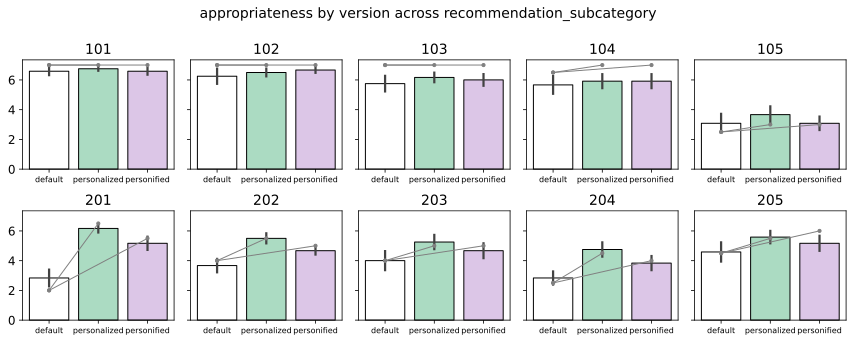

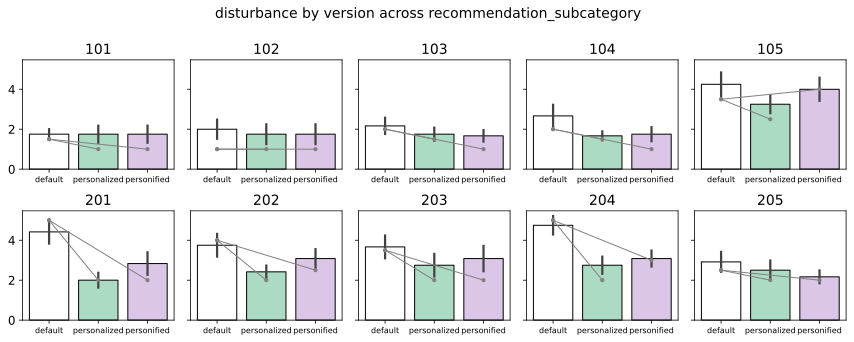

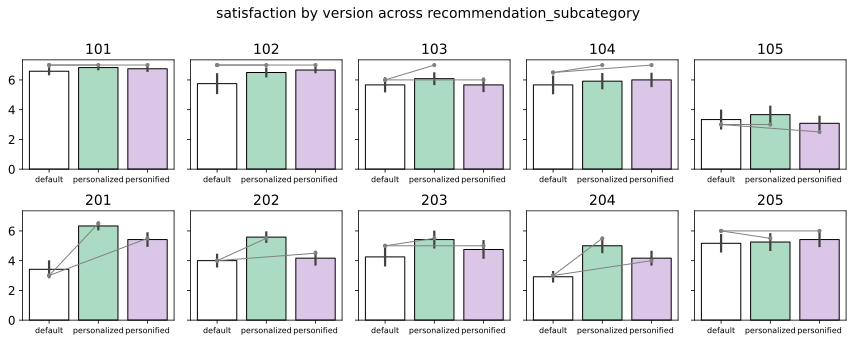

In [395]:
for metric in metrics:

    plotter.plot_metric_by_group_across_subcategories(
        df_reaction_merged_II,
        figsize_per_ax=(2.4,2.4),
        metric=metric,
        group="version",
        style="barplot",
        rotate_xticks=0,
    )

In [396]:
merge_keys = ["sub_id", "mode", "scene_id", "recommendation_subcategory"]

df_reaction_diff = df_reaction_II.copy()

for metric in metrics:
    df_reaction_diff = df_reaction_diff.merge(
        df_reaction[merge_keys + [metric]].rename(columns={metric: f"{metric}_base"}),
        on=merge_keys,
        how="left"
    )
    
    df_reaction_diff[f"{metric}_diff"] = (
        df_reaction_diff[metric] - df_reaction_diff[f"{metric}_base"]
    )

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


def test_subcategory_vs_category(
    df,
    metrics,
    version_col="version",
    subcategory_col="recommendation_subcategory",
    category_col="recommendation_category",
):
    results = []

    for version in df[version_col].dropna().unique():
        df_v = df[df[version_col] == version]

        for metric in metrics:

            for subcat in df_v[subcategory_col].dropna().unique():

                df_sub = df_v[df_v[subcategory_col] == subcat]

                if len(df_sub) < 3:
                    continue

                category = df_sub[category_col].iloc[0]

                # category 内其他 subcategory（排除自身）
                df_cat = df_v[df_v[category_col] == category]
                df_cat_rest = df_cat[df_cat[subcategory_col] != subcat]

                if len(df_cat_rest) < 3:
                    continue

                x = df_sub[metric].dropna().values
                y = df_cat_rest[metric].dropna().values

                if len(x) < 3 or len(y) < 3:
                    continue

                # -----------------------------
                # Welch t-test
                # -----------------------------
                stat, p_val = ttest_ind(x, y, equal_var=False)

                # -----------------------------
                # Welch dof
                # -----------------------------
                vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
                nx, ny = len(x), len(y)

                dof = (vx/nx + vy/ny)**2 / (
                    (vx**2)/((nx**2)*(nx-1)) + (vy**2)/((ny**2)*(ny-1))
                )

                # -----------------------------
                # Effect size (Cohen's d)
                # -----------------------------
                pooled_std = np.sqrt((vx + vy) / 2)
                effect_size = (x.mean() - y.mean()) / pooled_std if pooled_std > 0 else np.nan

                results.append({
                    "version": version,
                    "metric": metric,
                    "subcategory": subcat,
                    "p_val": p_val,
                    "stats": stat,
                    "dof": dof,
                    "effect_size": effect_size,
                })

    df_res = pd.DataFrame(results)

    # -----------------------------
    # FDR correction
    # -----------------------------
    if len(df_res) > 0:
        df_res["p_val_fdr"] = multipletests(df_res["p_val"], method="fdr_bh")[1]
    else:
        df_res["p_val_fdr"] = []

    return df_res

In [398]:
metrics = ['appropriateness', 'disturbance', 'satisfaction']

df_res = test_subcategory_vs_category(
    df_reaction,
    metrics
)

df_res = df_res.sort_values(["version", "metric", "subcategory"])
display(df_res)

,version,metric,subcategory,p_val,stats,dof,effect_size,p_val_fdr
1,default,appropriateness,101,3.260019e-11,6.975550,228.306716,0.734782,9.780058e-10
9,default,appropriateness,102,5.764932e-03,2.810543,121.785758,0.355206,1.441233e-02
5,default,appropriateness,103,5.733916e-01,0.564530,126.664044,0.070356,6.999465e-01
7,default,appropriateness,104,7.521266e-01,-0.316526,126.072787,-0.039513,8.058499e-01
3,default,appropriateness,105,9.664149e-09,-6.344704,87.095665,-0.929112,1.039611e-07
0,default,appropriateness,201,2.653091e-01,1.119491,112.789386,0.146228,4.208393e-01
4,default,appropriateness,202,5.030964e-01,0.671557,125.847002,0.083721,6.860405e-01
6,default,appropriateness,203,2.665315e-01,-1.117149,102.922656,-0.150695,4.208393e-01
8,default,appropriateness,204,4.455459e-03,-2.906399,105.608536,-0.387730,1.215125e-02
2,default,appropriateness,205,1.482189e-02,2.474568,113.249340,0.320850,3.176119e-02


In [399]:
metrics = ['appropriateness', 'disturbance', 'satisfaction']

df_res = test_subcategory_vs_category(
    df_reaction_II,
    metrics
)

df_res = df_res.sort_values(["version", "metric", "subcategory"])
display(df_res)

,version,metric,subcategory,p_val,stats,dof,effect_size,p_val_fdr
3,personalized,appropriateness,101,0.000135,4.089040,57.941533,0.906172,0.001353
9,personalized,appropriateness,102,0.022874,2.379464,35.283940,0.615932,0.085778
5,personalized,appropriateness,103,0.277213,1.108774,27.262759,0.306418,0.554427
1,personalized,appropriateness,104,0.786214,0.275379,17.702790,0.087346,0.941879
7,personalized,appropriateness,105,0.000494,-4.613600,12.913833,-1.695868,0.003293
2,personalized,appropriateness,201,0.015161,2.595793,26.648128,0.721828,0.064976
8,personalized,appropriateness,202,0.877525,0.155987,21.112520,0.046488,0.973150
4,personalized,appropriateness,203,0.636762,-0.481965,15.056347,-0.163695,0.830559
0,personalized,appropriateness,204,0.110835,-1.696335,14.738334,-0.581959,0.321325
6,personalized,appropriateness,205,0.724871,0.357862,16.923660,0.115544,0.906088


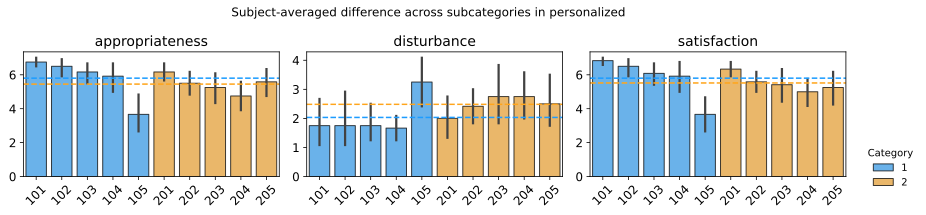

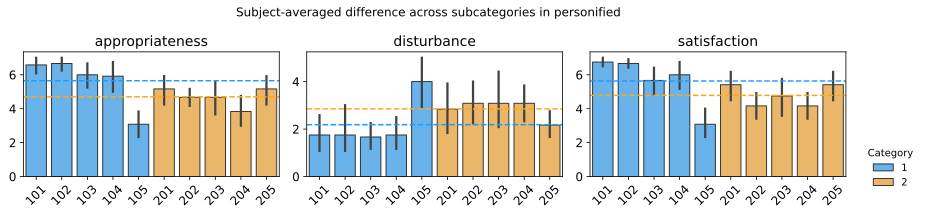

In [400]:
for version in df_reaction_II["version"].dropna().unique():
    df = df_reaction_II[df_reaction_II["version"] == version]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))


    for i, metric in enumerate(metrics):
        agg = (
            df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
            .mean()
            .reset_index()
        )

        agg["category"] = agg["recommendation_subcategory"].astype(int) // 100

        # type/category
        type_means = agg.groupby("category")[metric].mean()

        ax = axes[i] if len(metrics) > 1 else axes

        sns.barplot(
            data=agg,
            x="recommendation_subcategory",
            y=metric,
            hue="category",
            palette=type_palette,
            alpha=0.75,
            edgecolor="black",
            ax=ax
        )

        # type mean lines
        for cat, mean_val in type_means.items():
            ax.axhline(
                y=mean_val,
                color=type_palette.get(cat, "gray"),
                linestyle="--",
                linewidth=1.5,
                alpha=1.0,
            )

        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=45)
        ax.set_xlabel("")
        ax.set_ylabel("")

        if ax.get_legend() is not None:
            handles, labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()

    fig.suptitle(f"Subject-averaged difference across subcategories in {version}", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 1])

    fig.legend(
        handles,
        labels,
        title="Category",
        loc="lower left",
        bbox_to_anchor=(1.0, 0.1),
        frameon=False
    )

    plt.show()

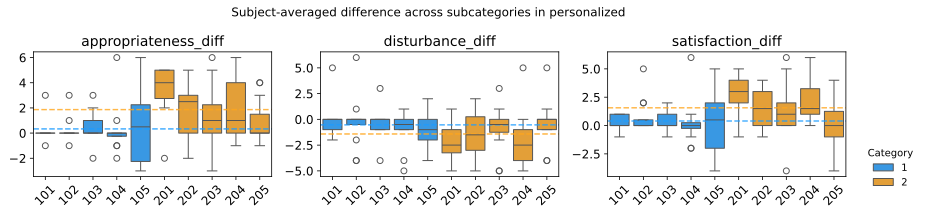

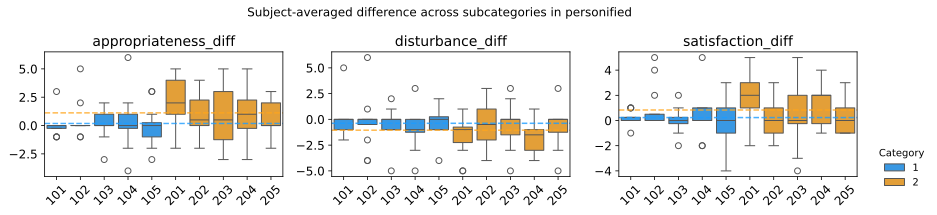

In [401]:
metrics_diff = [f"{m}_diff" for m in metrics]

for version in df_reaction_diff["version"].dropna().unique():
    df = df_reaction_diff[df_reaction_diff["version"] == version]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 3))


    for i, metric in enumerate(metrics_diff):
        agg = (
            df.groupby(["sub_id", "recommendation_subcategory"], observed=True)[metric]
            .mean()
            .reset_index()
        )

        agg["category"] = agg["recommendation_subcategory"].astype(int) // 100

        # type/category
        type_means = agg.groupby("category")[metric].mean()

        ax = axes[i] if len(metrics_diff) > 1 else axes

        sns.boxplot(
            data=agg,
            x="recommendation_subcategory",
            y=metric,
            hue="category",
            palette=type_palette,
            ax=ax
        )

        # type mean lines
        for cat, mean_val in type_means.items():
            ax.axhline(
                y=mean_val,
                color=type_palette.get(cat, "gray"),
                linestyle="--",
                linewidth=1.5,
                alpha=0.8,
            )

        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=45)
        ax.set_xlabel("")
        ax.set_ylabel("")

        if ax.get_legend() is not None:
            handles, labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()

    fig.suptitle(f"Subject-averaged difference across subcategories in {version}", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 1])

    fig.legend(
        handles,
        labels,
        title="Category",
        loc="lower left",
        bbox_to_anchor=(1.0, 0.1),
        frameon=False
    )

    plt.show()

## 4.2 Baseline Model: logistic regression and svm

In [92]:
features = [
    "subject_prior",
    "recommendation_intensity",
    "recommendation_coherence",
    "var_throttle_pre2s",
    "mean_throttle_pre2s",
    "car_density",
    "time_pressure",
    "mode",
    # "appropriateness",
    # "disturbance",
    # "satisfaction",
]

target = "accept"

logistic regression:
Accuracy per fold: [0.63212435 0.74611399 0.64583333 0.70833333 0.671875  ]
AUC per fold: [0.64735644 0.79819125 0.70536511 0.74149356 0.71505034]
Mean Accuracy: 0.6809 ± 0.0417
Mean AUC: 0.7215 ± 0.0492

Overall CV Accuracy: 0.6808731808731808
Overall CV AUC: 0.7140141793510025

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.62      0.55       295
           1       0.81      0.71      0.75       667

    accuracy                           0.68       962
   macro avg       0.65      0.66      0.65       962
weighted avg       0.71      0.68      0.69       962


Feature importance (mean ± std):
                    feature  coef_mean  coef_std  abs_mean  selection_freq
0             subject_prior   0.789756  0.064837  0.789756             1.0
6             time_pressure  -0.307194  0.049639  0.307194             1.0
2  recommendation_coherence   0.230509  0.041599  0.230509             1.0
5             

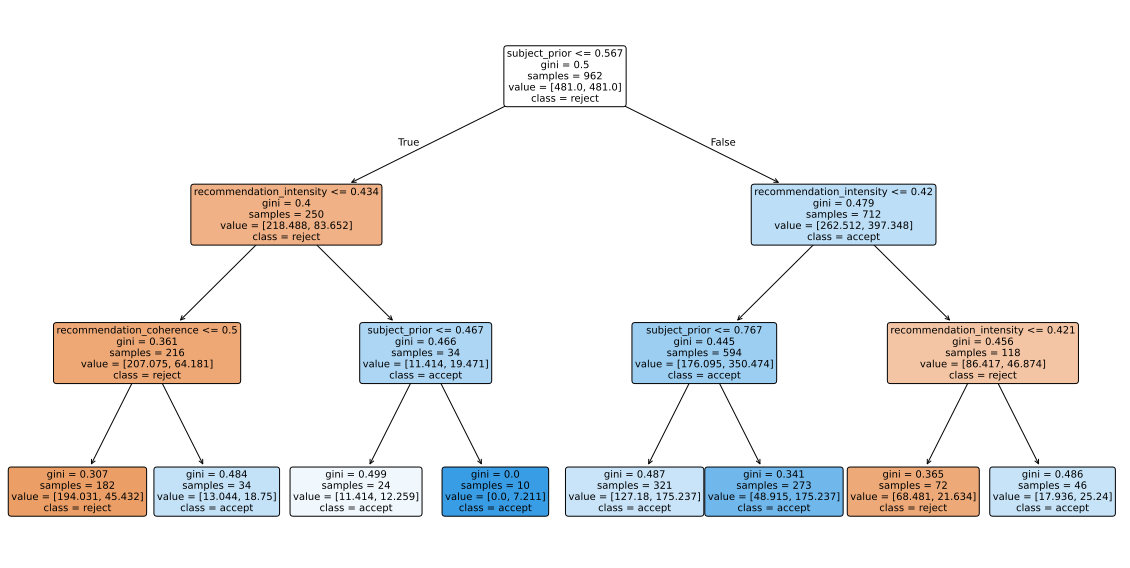

In [93]:
print("==============================================")
print("logistic regression:")
print("==============================================")

res_logistic = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="logistic",
    n_splits=5,
    class_weight="balanced"
)

print("==============================================")
print("svm:")
print("==============================================")

res_svm = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="svm",
    n_splits=5,
    class_weight="balanced"
)

print("==============================================")
print("mlp:")
print("==============================================")
res_mlp = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="mlp",
    n_splits=5,
    hidden_layer_sizes=(32, 8)
)

print("==============================================")
print("decision tree:")
print("==============================================")
res_tree = machinelearning.train_and_evaluate(
    df_reaction_all,
    features=features,
    target=target,
    model_type="tree",
    max_depth=3,
    min_samples_leaf=10,
    min_samples_split=20,
    class_weight="balanced",
    return_fold_models=True,
    fit_final_model=True
)

# evaluate decision tree
pipe = res_tree["final_model"]

tree = pipe.named_steps["clf"]

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=res_tree["features"],
    class_names=["reject", "accept"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [26]:
features = [
    "subject_prior",
    "recommendation_intensity",
    "recommendation_coherence",
    "var_throttle_pre2s",
    "mean_throttle_pre2s",
    "car_density",
    "time_pressure",
    "mode",
    "appropriateness",
    "disturbance",
    "satisfaction",
]

target = "accept"

In [27]:
print("==============================================")
print("logistic regression:")
print("==============================================")

res_logistic = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="logistic",
    n_splits=5,
    class_weight="balanced"
)

print("==============================================")
print("svm:")
print("==============================================")

res_svm = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="svm",
    n_splits=5,
    class_weight="balanced"
)

print("==============================================")
print("mlp:")
print("==============================================")
res_mlp = machinelearning.train_and_evaluate(
    df_reaction_all,
    features,
    target,
    model_type="mlp",
    n_splits=5,
    hidden_layer_sizes=(32, 8)
)

print("==============================================")
print("tree:")
print("==============================================")
res_tree = machinelearning.train_and_evaluate(
    df_reaction_all,
    features=features,
    target=target,
    model_type="tree",
    max_depth=3,
    min_samples_leaf=10,
    min_samples_split=20,
    class_weight="balanced",
    return_fold_models=True,
    fit_final_model=True
)

logistic regression:
Accuracy per fold: [0.79274611 0.8238342  0.84375    0.78645833 0.859375  ]
AUC per fold: [0.84821654 0.8518214  0.85605964 0.88339493 0.90773544]
Mean Accuracy: 0.8212 ± 0.0282
Mean AUC: 0.8694 ± 0.0228

Overall CV Accuracy: 0.8212058212058212
Overall CV AUC: 0.8686809137803979

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.77      0.73       295
           1       0.89      0.84      0.87       667

    accuracy                           0.82       962
   macro avg       0.79      0.81      0.80       962
weighted avg       0.83      0.82      0.82       962


Feature importance (mean ± std):
                     feature  coef_mean  coef_std  abs_mean  selection_freq
10              satisfaction   1.219201  0.082235  1.219201             1.0
0              subject_prior   0.561374  0.055385  0.561374             1.0
8            appropriateness   0.450453  0.101200  0.450453             1.0
2   recomm

## 4.3 1d Dynamics Simulation

The latent decision state `x` evolves as:

`change in x = leak + nonlinear term + input drive + noise`

More specifically:

`dx/dt = -lam * x + a * tanh(gain * (x - theta_dyn)) + u + noise`

where:

- `lam`: how strongly the state decays back
- `a`: strength of nonlinear attraction
- `gain`: steepness of the nonlinearity
- `theta_dyn`: center of the nonlinear curve
- `u`: evidence / pressure input
- `noise`: random fluctuation

Initial state:

`x0 = kappa * logit(p0)`

Decision readout:

`p_accept = sigmoid(x_final - theta_readout)`

Important:

- `theta_dyn` is part of the dynamics
- `theta_readout` is the final decision threshold
- nullcline means `dx/dt = 0`

In [28]:
dummy_row = pd.Series({

    # ---------------- meta ----------------
    "sub_id": 0,
    "scene_id": "scene_1",
    "mode": "manual",
    "trial_id": 0,
    "recommendation": "dummy recommendation",
    "recommendation_category": 1,
    "recommendation_subcategory": 101,

    # ---------------- prior ----------------
    "subject_prior": 0.5,
    "prior_mean_throttle_input": 0.0,
    "prior_var_throttle_input": 0.0,

    # ---------------- scenario ----------------
    "recommendation_intensity": 0.5,
    "recommendation_coherence": 1.0,
    "mean_throttle_input_zscore_pre2s": 0.0,
    "mean_throttle_pre2s": 0.0,
    "var_throttle_pre2s": 0.0,
    "car_density": 0.0,
    "time_pressure": 0,

    # ---------------- reaction ----------------
    "reaction": "ignore",
    "accept": False,
    "reaction_time_ms": np.nan,
    "mean_throttle_input_zscore_post5s": 0.0,
    "mean_throttle_post5s": 0.0,
    "var_throttle_post5s": 0.0,

    # ---------------- evaluation ----------------
    "appropriateness": 0.0,
    "disturbance": 0.0,
    "satisfaction": 0.0,

    # ---------------- bookkeeping ----------------
    "reaction__time_ms": 0.0,
    "trigger__time_ms": 0.0,
})

scene_id :scene_1, mode: manual, subcatgory: 101
===== Single Trial Demo (1D) =====
model = nonlinear_sigmoid
prior p0 = 0.500
x0 = -0.100
u = 1.780
lam_eff = 1.000
sigma_eff = 0.040
gain_eff = 1.500
theta_dyn = 0.000
theta_readout = 0.000
x_final = 4.210
p_accept = 0.985
predicted accept = 1
fixed points:
  x* = 4.264, stable, slope=-0.988


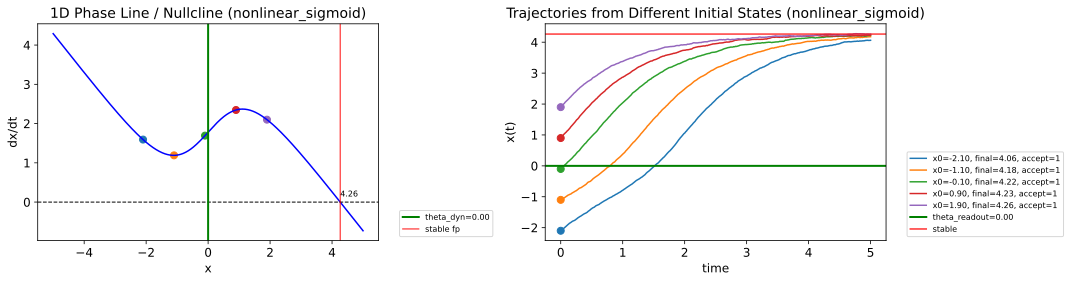

In [176]:
# row = df_reaction.iloc[400]
# beta_c = 0.3394
#   beta_i = 0.5997
#   beta_ci = 0.8067
#   gamma_throttle = 1.2526
#   gamma_density = 0.9690
#   gamma_time = 0.1459
#   gamma_mode = 0.9449
#   kappa = 1.0156
#   lam = 0.1712
#   a = 0.4175
#   gain = 0.7931
row = dummy_row
print(f"scene_id :{row['scene_id']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")

result = oneddynamics.run_single_trial_demo(
    row,
    model="nonlinear_sigmoid",
    beta_c=1.5,
    beta_i=0.5,
    beta_ci=0.1,

    gamma_throttle=0.1,
    gamma_density=0.1,
    gamma_time=0.3,
    gamma_mode=0.02,

    kappa=1.5,
    lam=1.0,
    a=2.5,
    gain=1.5,
    theta_dyn=0.0,

    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

In [29]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_reaction_all, groups=df_reaction_all["sub_id"]))

train_df = df_reaction_all.iloc[train_idx].copy()
test_df  = df_reaction_all.iloc[test_idx].copy()

In [409]:
fixed_params = dict(
    model="nonlinear_sigmoid",
    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

param_names = [
    "beta_c",
    "beta_i",
    "beta_ci",
    "gamma_throttle",
    "gamma_density",
    "gamma_time",
    "gamma_mode",
    "kappa",
    "lam",
    "a",
    "gain",
]

bounds = [
    (0.0, 5.0),   # beta_c
    (0.0, 5.0),   # beta_i
    (0.0, 5.0),   # beta_ci
    (0.0, 3.0),   # gamma_throttle
    (0.0, 3.0),   # gamma_density
    (0.0, 3.0),   # gamma_time
    (0.0, 3.0),   # gamma_mode
    (0.1, 5.0),    # kappa
    (0.1, 5.0),    # lam
    (0.1, 8.0),    # a
    (0.1, 8.0),    # gain
]

In [410]:
b_optimize = False

def objective(vec):
    loss = optim.objective(
        train_df,
        vec,
        oneddynamics.simulate_dataframe_decisions,
        fixed_params=fixed_params,
        param_names=param_names,
    )

    reg_lambda = 0.01
    reg = reg_lambda * np.sum(vec**2)

    return loss + reg

if b_optimize: 

    early_stopper = optim.EarlyStopper(
        patience=5,
        min_delta=1e-3,
        objective=objective,
    )

    result_de = differential_evolution(
        objective,
        bounds=bounds,
        strategy="best1bin",
        maxiter=100,
        popsize=10,
        tol=1e-3,
        mutation=(0.5, 1.0),
        recombination=0.7,
        polish=False,
        disp=True,
        workers=1,
        seed=42,
        callback=early_stopper,
    )

    print("DE total objective:", result_de.fun)
    print("DE best params:")
    best_params = {}
    for k, v in zip(param_names, result_de.x):
        best_params[k] = float(v)
        print(f"  {k} = {v:.4f}")


    result_local = minimize(
        objective,
        x0=result_de.x,
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 100,
            "ftol": 1e-4,
            "gtol": 1e-4,
        },
    )

    print("\nLocal total objective:", result_local.fun)
    print("Local best params:")
    best_params = {}
    for k, v in zip(param_names, result_local.x):
        best_params[k] = float(v)
        print(f"  {k} = {v:.4f}")

In [154]:
# Feature importance (mean ± std):
#                     feature  coef_mean  coef_std  abs_mean  selection_freq
# 0             subject_prior   0.789756  0.064837  0.789756             1.0
# 6             time_pressure  -0.307194  0.049639  0.307194             1.0
# 2  recommendation_coherence   0.230509  0.041599  0.230509             1.0
# 5               car_density  -0.087540  0.066559  0.087540             0.8
# 3        var_throttle_pre2s  -0.083604  0.255799  0.083604             1.0
# 1  recommendation_intensity  -0.078592  0.022032  0.078592             1.0
# 7                      mode   0.029177  0.045288  0.029177             0.8
# 4       mean_throttle_pre2s   0.028614  0.383067  0.028614             1.0

manual_params = {
    "model": "nonlinear_sigmoid",
    "beta_c": 1.5,
    "beta_i": 0.5,
    "beta_ci": 0.25,
    
    "gamma_throttle": 0.15,
    "gamma_density": 0.08,
    "gamma_time": 0.25,
    "gamma_mode": 0.005,

    "kappa": 1.5,
    "lam": 1.0,
    "a": 2.5,
    "gain": 1.5,
    "theta_dyn": 0.0,

    "sigma": 0.04,
    "theta_readout": 0.0,
    "dt": 0.01,
    "T": 5.0,
    
    "density_lam_gain": 0.0,
    "density_sigma_gain": 0.0,
    "time_gain_multiplier": 1.0,
    "auto_lam_multiplier": 1.0,
    "auto_sigma_multiplier": 1.0,
}


In [156]:
# final_params = dict(fixed_params)
# final_params.update(best_params)

df_sim_test = oneddynamics.simulate_dataframe_decisions(
    test_df,
    **manual_params
)

valid = df_sim_test.dropna(subset=["accept_true", "p_accept_pred"]).copy()
y_true = valid["accept_true"].astype(int).values
y_prob = np.clip(valid["p_accept_pred"].astype(float).values, 1e-6, 1 - 1e-6)
y_pred = (y_prob >= 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Test AUC:", roc_auc_score(y_true, y_prob))
print("Test LogLoss:", log_loss(y_true, y_prob))

# final_loss = optim.objective(
#     train_df,
#     result_de.x,
#     oneddynamics.simulate_dataframe_decisions,
#     fixed_params=fixed_params,
#     param_names=param_names,
# )
# reg = 0.01 * np.sum(result_de.x**2)

# print("DE objective (no reg):", final_loss)
# print("DE reg:", reg)
# print("DE total objective:", result_de.fun)
# print("DE accuracy approx:", -final_loss)

Test Accuracy: 0.6947368421052632
Test AUC: 0.71565456940951
Test LogLoss: 0.6426483404974469


In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_sim_test["accept_true"], df_sim_test["accept_pred"])
print(cm)

[[ 29  31]
 [ 15 115]]


In [64]:
corr_df = oneddynamics.build_dynamical_correction_features(df_reaction_all)
df_model = df_reaction_all.join(corr_df.set_index("idx"), how="left")

In [65]:
df_model[["xT_nonlinear", "accept"]].corr()

,xT_nonlinear,accept
xT_nonlinear,1.000000,0.294129
accept,0.294129,1.000000


In [95]:
X_base = df_model[features]
y = df_model["accept"].astype(int)

dynamics_feature = features + ["delta_nonlinear_extra",]
X_corr = df_model[dynamics_feature]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X = X_corr
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

coef = pipe.named_steps["clf"].coef_[0]
feature_importance = pd.Series(coef, index=dynamics_feature).sort_values()

print(feature_importance)

Accuracy: 0.7150259067357513
AUC: 0.7079433341765746
              precision    recall  f1-score   support

           0       0.55      0.41      0.47        59
           1       0.77      0.85      0.81       134

    accuracy                           0.72       193
   macro avg       0.66      0.63      0.64       193
weighted avg       0.70      0.72      0.70       193

time_pressure              -0.352233
mean_throttle_pre2s        -0.208387
recommendation_intensity   -0.070383
car_density                -0.008618
mode                        0.020447
delta_nonlinear_extra       0.039017
var_throttle_pre2s          0.076061
recommendation_coherence    0.302830
subject_prior               0.822878
dtype: float64


In [175]:
# Feature importance (mean ± std):
#                     feature  coef_mean  coef_std  abs_mean  selection_freq
# 0             subject_prior   0.789756  0.064837  0.789756             1.0
# 6             time_pressure  -0.307194  0.049639  0.307194             1.0
# 2  recommendation_coherence   0.230509  0.041599  0.230509             1.0
# 5               car_density  -0.087540  0.066559  0.087540             0.8
# 3        var_throttle_pre2s  -0.083604  0.255799  0.083604             1.0
# 1  recommendation_intensity  -0.078592  0.022032  0.078592             1.0
# 7                      mode   0.029177  0.045288  0.029177             0.8
# 4       mean_throttle_pre2s   0.028614  0.383067  0.028614             1.0

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# =========================
# config
# =========================
n_splits = 5
groups = df_reaction_all["sub_id"]

sim_params = dict(
    model="nonlinear_sigmoid",
    beta_c=1.5,
    beta_i=0.5,
    beta_ci=0.1,

    gamma_throttle=0.1,
    gamma_density=0.1,
    gamma_time=0.3,
    gamma_mode=0.02,

    kappa=1.5,
    lam=1.0,
    a=3.0,
    gain=1.5,
    theta_dyn=0.0,

    sigma=0.04,
    theta_readout=0.0,
    dt=0.01,
    T=5.0,
    
    density_lam_gain=0.0,
    density_sigma_gain=0.0,
    time_gain_multiplier=1.0,
    auto_lam_multiplier=1.0,
    auto_sigma_multiplier=1.0,
)

# =========================
# CV
# =========================
gkf = GroupKFold(n_splits=n_splits)

rows = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df_reaction_all, groups=groups), start=1
):
    train_df = df_reaction_all.iloc[train_idx].copy()
    test_df  = df_reaction_all.iloc[test_idx].copy()

    df_sim_test = oneddynamics.simulate_dataframe_decisions(
        test_df,
        **sim_params
    )

    valid = df_sim_test.dropna(subset=["accept_true", "accept_pred"]).copy()

    if len(valid) == 0:
        acc = np.nan
        auc = np.nan
        nll = np.nan
        accept_rate = np.nan
    else:
        y_true = valid["accept_true"].astype(int).values
        y_prob = np.clip(valid["accept_pred"].astype(float).values, 1e-6, 1 - 1e-6)
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_true, y_pred)

        if len(np.unique(y_true)) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_true, y_prob)

        nll = log_loss(y_true, y_prob)
        accept_rate = y_true.mean()

    rows.append({
        "fold": fold,
        "n_valid": len(valid),
        "accept_rate": accept_rate,
        "acc": acc,
        "auc": auc,
        "logloss": nll,
    })

    print(f"Fold {fold}:")
    print(f"  n_valid = {len(valid)}")
    print(f"  original acceptance rate = {accept_rate:.4f}" if pd.notna(accept_rate) else "  original acceptance rate = nan")
    print(f"  accuracy = {acc:.4f}" if pd.notna(acc) else "  accuracy = nan")
    print(f"  auc = {auc:.4f}" if pd.notna(auc) else "  auc = nan")
    print(f"  logloss = {nll:.4f}" if pd.notna(nll) else "  logloss = nan")
    print()

# =========================
# summary
# =========================
cv_results = pd.DataFrame(rows)

print("===== Overall CV Results =====")
print(f"ACC     mean = {cv_results['acc'].mean():.4f}, std = {cv_results['acc'].std(ddof=1):.4f}")
print(f"AUC     mean = {cv_results['auc'].mean():.4f}, std = {cv_results['auc'].std(ddof=1):.4f}")
print(f"LogLoss mean = {cv_results['logloss'].mean():.4f}, std = {cv_results['logloss'].std(ddof=1):.4f}")

display(cv_results)

Fold 1:
  n_valid = 210
  original acceptance rate = 0.6619
  accuracy = 0.7238
  auc = 0.6811
  logloss = 3.8157

Fold 2:
  n_valid = 180
  original acceptance rate = 0.7222
  accuracy = 0.7556
  auc = 0.6338
  logloss = 3.3771

Fold 3:
  n_valid = 191
  original acceptance rate = 0.7644
  accuracy = 0.7592
  auc = 0.5427
  logloss = 3.3273

Fold 4:
  n_valid = 191
  original acceptance rate = 0.6859
  accuracy = 0.7068
  auc = 0.6282
  logloss = 4.0506

Fold 5:
  n_valid = 190
  original acceptance rate = 0.6368
  accuracy = 0.7158
  auc = 0.6803
  logloss = 3.9265

===== Overall CV Results =====
ACC     mean = 0.7322, std = 0.0238
AUC     mean = 0.6332, std = 0.0564
LogLoss mean = 3.6995, std = 0.3282


,fold,n_valid,accept_rate,acc,auc,logloss
0,1,210,0.661905,0.723810,0.681123,3.815713
1,2,180,0.722222,0.755556,0.633846,3.377126
2,3,191,0.764398,0.759162,0.542694,3.327296
3,4,191,0.685864,0.706806,0.628181,4.050622
4,5,190,0.636842,0.715789,0.680321,3.926514


## 4.4 2d dynamics

The latent decision states \(x\) (accept) and \(y\) (reject) evolve as:

`change in state = leak + nonlinear term + input drive + noise`

---

### Dynamics

For accept state:

`dx/dt = -lam_x * x + phi_x(x + w_xy * y) + f_x + noise_x`

For reject state:

`dy/dt = -lam_y * y + phi_y(y + w_yx * x) + f_y + noise_y`

---

### Nonlinearity (Cubic)

`phi(z) = z - a * z^3`

- creates saturation and multi-stability  
- allows curved nullclines and attractor competition  

---

### Inputs (Drives)

Accept drive:

`f_x = alpha_prior * logit(p0)
     + alpha_coherence * coherence
     + alpha_intensity * intensity
     + alpha_ci * coherence * intensity
     + alpha_density * car_density`

Reject drive:

`f_y = beta_pressure * effective_pressure
     + beta_density * car_density
     + beta_time_pressure * time_pressure
     + beta_low_coherence * (1 - coherence)
     + beta_prior * (-logit(p0))`

---

### Context Modulation

`effective_pressure = pressure`

- reduced in auto mode via `auto_pressure_reduction`
- scaled by:
  - `density_pressure_gain`
  - `time_pressure_gain`

---

### Initial State

`x0 = kappa * logit(p0)`  
`y0 = -kappa * logit(p0)`

---

### Decision Readout

`decision = accept if (x_final - y_final) > theta`

or probabilistic:

`p_accept = sigmoid(x_final - y_final - theta)`

---

### Key Parameters

- `lam_x, lam_y`: decay (leak)
- `w_xy, w_yx`: cross-coupling (competition / excitation)
- `a`: cubic nonlinearity strength
- `sigma_x, sigma_y`: noise level
- `theta`: decision threshold

---

### Important

- competition is **implicit via coupling (w_xy, w_yx)**  
- nonlinearity shapes **attractor landscape**  
- prior enters both:
  - initial condition  
  - asymmetric drives (f_x vs f_y)  
- system outcome depends on **fixed points + trajectory**

---

### Nullcline

Nullcline is defined as:

`dx/dt = 0` and `dy/dt = 0`

Their intersection gives **fixed points** (decision attractors).


===== Single Trial Demo (2D unified nonlinear) =====
prior_accept_prob = 0.600
coherence = 1.000
intensity = 0.299
stim_raw = 2.374
stim_on_x = 0.998
stim_on_y = 1.000
effective_pressure = 0.010
accept drive f_x = 2.374
reject drive f_y = 0.021
initial state = (0.159, -0.159)
fixed point = (0.665, -0.973)
final state = (0.653, -0.996)
final diff x-y = 1.649
p_accept = 0.839
accept_pred = 1


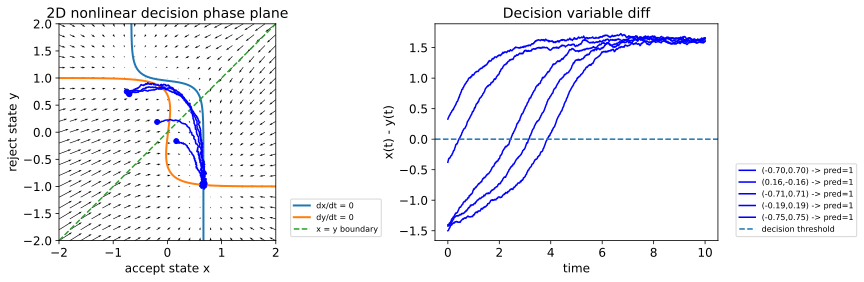

In [182]:
row = df_reaction_all.iloc[800]
row = df_reaction_all.iloc[812]
# row = dummy_row
# print(f"scene_id :{row['scene_id']}, version: {row['version']}, mode: {row['mode']}, subcatgory: {row['recommendation_subcategory']}")

demo = twoddynamics.run_single_trial_demo_2d(
    row,
    auto_pressure_reduction=0.02,
    density_pressure_gain=0.05,
    time_pressure_gain=0.2,

    alpha_coherence=2.0,
    alpha_intensity=1.0,
    alpha_ci=0.25,

    beta_pressure=0.05,
    beta_density=0.1,
    beta_time_pressure=0.3,

    k_init=1.5,
    lam_x=1.5,
    lam_y=1.0,
    w_xy=2.5,
    w_yx=1.5,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,
    symmetric_gate=False,
)

In [187]:
# df_type_two = df_reaction[df_reaction["recommendation_category"] == 2]

# Feature importance (mean ± std):
#                     feature  coef_mean  coef_std  abs_mean  selection_freq
# 0             subject_prior   0.789756  0.064837  0.789756             1.0
# 6             time_pressure  -0.307194  0.049639  0.307194             1.0
# 2  recommendation_coherence   0.230509  0.041599  0.230509             1.0
# 5               car_density  -0.087540  0.066559  0.087540             0.8
# 3        var_throttle_pre2s  -0.083604  0.255799  0.083604             1.0
# 1  recommendation_intensity  -0.078592  0.022032  0.078592             1.0
# 7                      mode   0.029177  0.045288  0.029177             0.8
# 4       mean_throttle_pre2s   0.028614  0.383067  0.028614             1.0

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# =========================
# config
# =========================
n_splits = 5
groups = df_reaction_all["sub_id"]

sim_params = dict(
    auto_pressure_reduction=0.02,
    density_pressure_gain=0.05,
    time_pressure_gain=0.2,

    alpha_coherence=2.0,
    alpha_intensity=1.0,
    alpha_ci=0.25,

    beta_pressure=0.05,
    beta_density=0.1,
    beta_time_pressure=0.3,

    k_init=1.5,
    lam_x=1.5,
    lam_y=1.0,
    w_xy=2.5,
    w_yx=1.5,
    sigma_x=0.04,
    sigma_y=0.04,
    T=10.0,
    decision_threshold=0.0,
    symmetric_gate=False,
)

# =========================
# CV
# =========================
gkf = GroupKFold(n_splits=n_splits)

rows = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(df_reaction_all, groups=groups), start=1
):
    train_df = df_reaction_all.iloc[train_idx].copy()
    test_df  = df_reaction_all.iloc[test_idx].copy()

    df_sim_test = twoddynamics.simulate_dataframe_2d(
        test_df,
        **sim_params
    )

    valid = df_sim_test.dropna(subset=["accept_true", "accept_pred"]).copy()

    if len(valid) == 0:
        acc = np.nan
        auc = np.nan
        nll = np.nan
        accept_rate = np.nan
    else:
        y_true = valid["accept_true"].astype(int).values
        y_prob = np.clip(valid["accept_pred"].astype(float).values, 1e-6, 1 - 1e-6)
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_true, y_pred)

        if len(np.unique(y_true)) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_true, y_prob)

        nll = log_loss(y_true, y_prob)
        accept_rate = y_true.mean()

    rows.append({
        "fold": fold,
        "n_valid": len(valid),
        "accept_rate": accept_rate,
        "acc": acc,
        "auc": auc,
        "logloss": nll,
    })

    print(f"Fold {fold}:")
    print(f"  n_valid = {len(valid)}")
    print(f"  original acceptance rate = {accept_rate:.4f}" if pd.notna(accept_rate) else "  original acceptance rate = nan")
    print(f"  accuracy = {acc:.4f}" if pd.notna(acc) else "  accuracy = nan")
    print(f"  auc = {auc:.4f}" if pd.notna(auc) else "  auc = nan")
    print(f"  logloss = {nll:.4f}" if pd.notna(nll) else "  logloss = nan")
    print()

# =========================
# summary
# =========================
cv_results = pd.DataFrame(rows)

print("===== Overall CV Results =====")
print(f"ACC     mean = {cv_results['acc'].mean():.4f}, std = {cv_results['acc'].std(ddof=1):.4f}")
print(f"AUC     mean = {cv_results['auc'].mean():.4f}, std = {cv_results['auc'].std(ddof=1):.4f}")
print(f"LogLoss mean = {cv_results['logloss'].mean():.4f}, std = {cv_results['logloss'].std(ddof=1):.4f}")

display(cv_results)

Fold 1:
  n_valid = 210
  original acceptance rate = 0.6619
  accuracy = 0.7333
  auc = 0.6883
  logloss = 3.6841

Fold 2:
  n_valid = 180
  original acceptance rate = 0.7222
  accuracy = 0.7667
  auc = 0.6169
  logloss = 3.2236

Fold 3:
  n_valid = 191
  original acceptance rate = 0.7644
  accuracy = 0.7644
  auc = 0.5077
  logloss = 3.2550

Fold 4:
  n_valid = 191
  original acceptance rate = 0.6859
  accuracy = 0.7435
  auc = 0.6504
  logloss = 3.5443

Fold 5:
  n_valid = 190
  original acceptance rate = 0.6368
  accuracy = 0.7105
  auc = 0.6700
  logloss = 3.9992

===== Overall CV Results =====
ACC     mean = 0.7437, std = 0.0233
AUC     mean = 0.6267, std = 0.0716
LogLoss mean = 3.5412, std = 0.3213


,fold,n_valid,accept_rate,acc,auc,logloss
0,1,210,0.661905,0.733333,0.688317,3.684137
1,2,180,0.722222,0.766667,0.616923,3.223620
2,3,191,0.764398,0.764398,0.507686,3.254964
3,4,191,0.685864,0.743455,0.650382,3.544294
4,5,190,0.636842,0.710526,0.669960,3.999227


In [184]:
valid = df_sim_test.dropna(subset=["accept_true"]).copy()

print("true accept rate =", valid["accept_true"].mean())
print("pred accept rate =", valid["accept_pred"].mean())

cm = pd.crosstab(
    valid["accept_true"],
    valid["accept_pred"],
    rownames=["true"],
    colnames=["pred"],
    dropna=False
)
print(cm)

true accept rate = 0.6368421052631579
pred accept rate = 0.6842105263157895
pred   0   1
true        
0     36  33
1     24  97


In [185]:
valid = df_sim_test.dropna(subset=["accept_true"]).copy()

print(valid[["f_x", "f_y"]].describe())
print("mean f_x =", valid["f_x"].mean())
print("mean f_y =", valid["f_y"].mean())
print("mean f_x - f_y =", (valid["f_x"] - valid["f_y"]).mean())

              f_x         f_y
count  190.000000  190.000000
mean     0.528386    0.140930
std      0.631496    0.152754
min      0.000000    0.020500
25%      0.210732    0.020500
50%      0.369091    0.082000
75%      0.420000    0.392000
max      2.538889    0.392221
mean f_x = 0.5283855092276144
mean f_y = 0.1409304757449176
mean f_x - f_y = 0.38745503348269683
